# RL Network-Markowitz Portfolio Optimization
### Thesis-Ready Version (Fixed) — Multi-Seed SAC + Ablation Study + XAI Analysis

**Ringkasan perbaikan dari versi sebelumnya:**
- Duplikasi definisi fungsi dihapus (tiap fungsi hanya didefinisikan sekali)
- Cache key diubah ke tuple `('train', i)` / `('test', i)` agar tidak collision
- `compute_market_features`: parameter `port_val` yang tidak dipakai dihapus
- `_solve_weights`: menambahkan `warnings.warn` saat fallback ke equal-weight
- `get_obs_dim` & `build_observation`: konsisten — raise `ValueError` jika keduanya False
- `AblationPortfolioEnv`: `_rew_stats` di-reset tiap `reset()` (bukan akumulasi lintas episode)
- `AblationPortfolioEnv`: parameter `split='train'/'test'` menggantikan `data_start_offset` integer
- `run_wilcoxon_tests` sekarang dipanggil di Final Analysis dan hasilnya ditampilkan
- Label `Features` di dashboard diperbaiki: `Network(2) + Market(7)` (bukan 5+4)
- `FEATURE_NAMES` dikelompokkan dengan komentar agar sesuai implementasi
- `plot_shap_analysis`: background & explain sample diperbesar; skip jika model None
- Judul notebook disesuaikan: CVaR adalah metrik evaluasi, bukan reward RL
- - **[v5] `StepLoggerCallback` menggantikan `RewardLoggerCallback`: log reward + std setiap 500 steps untuk analisis konvergensi berbasis train-step**
- **[v5] `plot_convergence_analysis()`: 3-panel justifikasi konvergensi (mean reward, rolling std, diminishing returns per 2k-step interval)**
- **[v4] Normalisasi konsisten: market features (7) kini di-Z-score dari statistik training,
  sama seperti network features — menghilangkan inkonsistensi skala antar feature group**


## 1. Imports & Global Settings

In [1]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import networkx as nx
import seaborn as sns
import shap
import torch
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import SAC
from stable_baselines3.common.callbacks import BaseCallback, EvalCallback
from tqdm.notebook import tqdm
from scipy import stats
from scipy.optimize import minimize
from IPython.display import display

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# ================================================================
# GLOBAL SETTINGS
# ================================================================
SEEDS         = [42]#[42, 123, 77]
TRAIN_STEPS   = 10000
FORCE_RETRAIN = True    # Set False jika model sudah ada
SET_WINDOW    = 30
SET_REBALANCE = 7
REWARD_WINDOW = 20
CVAR_LEVEL    = 0.95    # CVaR digunakan sebagai metrik evaluasi, bukan reward
STAT_ALPHA    = 0.05
SAVE_IMAGES   = False

ABLATION_CONFIGS = {
    'E2_Sharpe'          : {'use_network': True,  'use_market': True,  'reward_type': 'sharpe'},
    'E2_Sortino'         : {'use_network': True,  'use_market': True,  'reward_type': 'sortino'},
    'E2_Calmar'          : {'use_network': True,  'use_market': True,  'reward_type': 'calmar'},
    'E2_Ulcer'           : {'use_network': True,  'use_market': True,  'reward_type': 'ulcer'},
    'E2_Ensemble_Avg'    : {'use_network': True,  'use_market': True,  'is_ensemble': True},
    #'Comp_Static_Gamma0' : {'use_network': True,  'use_market': False, 'static_gamma': 0.0},
    #'Comp_Static_Gamma1' : {'use_network': True,  'use_market': False, 'static_gamma': 1.0},
    'Comp_Static_Gamma2' : {'use_network': True,  'use_market': False, 'static_gamma': 2.0},
    # Buy-and-Hold: gamma awal dihitung satu kali, tidak di-update tiap step
    'BuyHold_Markowitz'  : {'use_network': True,  'use_market': False, 'is_buyhold': True},
    'EqualWeight'        : {'is_equal_weight': True},
}

EVAL_METRICS = ['Sharpe Ratio', 'Sortino Ratio', 'Calmar Ratio', 'Ulcer Index']

SCRIPT_DIR = os.getcwd()
OUTPUT_DIR = os.path.join(SCRIPT_DIR, 'ablation_results_thesis')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Environment initialized.')
print(f'Output dir: {OUTPUT_DIR}')



Environment initialized.
Output dir: g:\My Drive\00_Kuliah\Thesis\sharpenThesis_dpInsya\guidici_reexperiment_clean2\ablation_results_thesis


## 2. Data Loading

In [2]:
file_data = 'crypto_data_real.xlsx'

def load_and_split(filename, train_split=0.7):
    df = pd.read_excel(filename, sheet_name='Returns', index_col=0)
    df.index = pd.to_datetime(df.index)
    assets = list(df.columns)
    if 'USDT' in assets:
        assets.remove('USDT')
    assets.sort()
    df = df[assets]
    split_idx = int(len(df) * train_split)
    return df.iloc[:split_idx], df.iloc[split_idx:], assets

ret_train, ret_test, assets = load_and_split(file_data)

print(f'Assets  : {len(assets)} — {assets}')
print(f'Training: {ret_train.index[0].date()} to {ret_train.index[-1].date()} ({len(ret_train)} rows)')
print(f'Testing : {ret_test.index[0].date()} to {ret_test.index[-1].date()} ({len(ret_test)} rows)')


Assets  : 9 — ['BCH', 'BNB', 'BTC', 'EOS', 'ETH', 'LTC', 'TRX', 'XLM', 'XRP']
Training: 2017-09-15 to 2019-03-02 (534 rows)
Testing : 2019-03-03 to 2019-10-17 (229 rows)


## 3. Portfolio Optimization Logic

In [3]:
def apply_rmt_filter(returns_window):
    """Random Matrix Theory denoising filter pada correlation matrix."""
    T, N = returns_window.shape
    corr_mat = returns_window.corr().fillna(0).values
    eigenvalues, eigenvectors = np.linalg.eigh(corr_mat)
    Q = T / N
    lambda_max = (1 + np.sqrt(1 / Q)) ** 2
    n_signal = np.sum(eigenvalues >= lambda_max)
    if n_signal == 0:
        eigenvalues[:-1] = 0
    else:
        eigenvalues[eigenvalues < lambda_max] = 0
    corr_denoised = eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T
    np.fill_diagonal(corr_denoised, 1)
    return corr_denoised


def _solve_weights(cov_f, cent_vec, mu, gamma, n_assets):
    """
    Minimisasi: w^T * cov_f * w + gamma * cent_vec^T * w
    subject to: sum(w)=1, long-only, dan opsional return constraint.
    FIX: menambahkan warning eksplisit saat fallback ke equal-weight.
    """
    fun    = lambda w: w.T @ cov_f @ w + gamma * np.sum(cent_vec * w)
    w0     = np.ones(n_assets) / n_assets
    bounds = tuple((0.0, 1.0) for _ in range(n_assets))
    cons_with_ret = (
        {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
        {'type': 'ineq', 'fun': lambda w: np.dot(w, mu) - np.mean(mu)},
    )
    cons_no_ret = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1},)
    res = minimize(fun, w0, method='SLSQP', bounds=bounds, constraints=cons_with_ret)
    if res.success:
        return res.x
    res2 = minimize(fun, w0, method='SLSQP', bounds=bounds, constraints=cons_no_ret)
    if res2.success:
        return res2.x
    # FIX: warn secara eksplisit — jangan diam-diam fallback
    warnings.warn(
        f'Optimization failed (gamma={gamma:.3f}). Falling back to equal-weight.',
        RuntimeWarning, stacklevel=2
    )
    return w0


def _build_mst_centrality(N, corr_f):
    """Bangun MST dari RMT-denoised correlation matrix, hitung eigenvector centrality."""
    dist_mat = np.sqrt(np.maximum(0, 2 * (1 - corr_f)))
    G_full   = nx.from_numpy_array(dist_mat)
    mst      = nx.minimum_spanning_tree(G_full)
    try:
        centrality = nx.eigenvector_centrality(mst, max_iter=300)
        cent_vec   = np.array([centrality[i] for i in range(N)])
    except Exception:
        cent_vec = np.array(list(nx.degree_centrality(mst).values()))
    return mst, cent_vec


def fast_centrality_weights(cov_f, cent_vec, mu, gamma):
    return _solve_weights(cov_f, cent_vec, mu, gamma, len(mu))


def compute_classic_mv_weights(returns_window):
    """Mean-Variance klasik Markowitz sebagai baseline."""
    T, N = returns_window.shape
    mu   = returns_window.mean().values
    cov  = np.cov(returns_window.values.T) + np.eye(N) * 1e-8
    w0     = np.ones(N) / N
    bounds = tuple((0.0, 1.0) for _ in range(N))
    fun    = lambda w: w @ cov @ w
    cons_with_ret = (
        {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
        {'type': 'ineq', 'fun': lambda w: np.dot(w, mu) - np.mean(mu)},
    )
    cons_no_ret = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1},)
    res = minimize(fun, w0, method='SLSQP', bounds=bounds, constraints=cons_with_ret)
    if res.success:
        return res.x
    res2 = minimize(fun, w0, method='SLSQP', bounds=bounds, constraints=cons_no_ret)
    return res2.x if res2.success else w0


## 4. Metrics & Helpers

In [4]:
def _compute_drawdown(arr):
    cumulative = (1 + arr).cumprod()
    peak = np.maximum.accumulate(cumulative)
    dd   = (cumulative - peak) / peak
    return dd, cumulative


def calculate_annualized_return(ret_series, periods_per_year=252):
    arr = np.array(ret_series)
    n   = len(arr)
    if n == 0:
        return np.nan
    total = (1 + arr).prod()
    if total <= 0:
        return np.nan
    return total ** (periods_per_year / n) - 1


def calculate_sharpe_ratio(ret_series, periods_per_year=252):
    arr     = np.array(ret_series)
    ann_ret = calculate_annualized_return(arr, periods_per_year)
    ann_vol = arr.std() * np.sqrt(periods_per_year)
    return ann_ret / ann_vol if ann_vol > 0 else 0.0


def calculate_sortino_ratio(ret_series, periods_per_year=252, mar=0.0):
    arr      = np.array(ret_series)
    ann_ret  = calculate_annualized_return(arr, periods_per_year)
    downside = arr[arr < mar]
    if len(downside) == 0:
        return 0.0
    downside_dev = np.std(downside) * np.sqrt(periods_per_year)
    return ann_ret / downside_dev if downside_dev > 0 else 0.0


def calculate_calmar_ratio(ret_series, periods_per_year=252):
    arr     = np.array(ret_series)
    ann_ret = calculate_annualized_return(arr, periods_per_year)
    dd, _   = _compute_drawdown(arr)
    max_dd  = dd.min()
    return ann_ret / abs(max_dd) if abs(max_dd) > 1e-8 else 0.0


def calculate_cvar(ret_series, confidence=0.95):
    """Conditional Value-at-Risk (CVaR / Expected Shortfall).
    Digunakan sebagai metrik EVALUASI, bukan sebagai fungsi reward RL."""
    arr = np.array(ret_series)
    if len(arr) == 0:
        return 0.0
    var         = np.percentile(arr, (1 - confidence) * 100)
    tail_losses = arr[arr <= var]
    return float(-np.mean(tail_losses)) if len(tail_losses) > 0 else 0.0


def calculate_ulcer_index(ret_series):
    arr = np.array(ret_series)
    if len(arr) == 0:
        return 0.0
    cumulative = (1 + arr).cumprod()
    peak = np.maximum.accumulate(cumulative)
    dd   = (cumulative - peak) / peak
    return float(np.sqrt(np.mean(dd ** 2)))


def calculate_all_metrics(ret_series, cvar_level=0.95, periods_per_year=252):
    arr     = np.array(ret_series)
    ann_ret = calculate_annualized_return(arr, periods_per_year)
    ann_vol = arr.std() * np.sqrt(periods_per_year)
    dd, _   = _compute_drawdown(arr)
    return {
        'Sharpe Ratio'    : calculate_sharpe_ratio(arr, periods_per_year),
        'Sortino Ratio'   : calculate_sortino_ratio(arr, periods_per_year),
        'Calmar Ratio'    : calculate_calmar_ratio(arr, periods_per_year),
        'CVaR (95%)'      : calculate_cvar(arr, cvar_level),
        'Total Return'    : (1 + arr).prod() - 1,
        'Ann. Return'     : ann_ret,
        'Ann. Volatility' : ann_vol,
        'Max Drawdown'    : dd.min(),
        'Ulcer Index'     : calculate_ulcer_index(arr),
    }


## 5. Visualization Helpers

In [5]:
ABLATION_COLORS = {
    'E2_Sharpe'          : '#FF0000',
    'E2_Sortino'         : '#FFD700',
    'E2_Calmar'          : '#008000',
    'E2_Ulcer'           : '#0000FF',
    'E2_Ensemble_Avg'    : '#800080',
    'Comp_Static_Gamma0' : '#FFD700',
    'Comp_Static_Gamma1' : '#800080',
    'Comp_Static_Gamma2' : '#000000',
    'Classic-MV'         : '#FF0000',
    'BuyHold_Markowitz'  : '#008000',
    'EqualWeight'        : '#0000FF',
}

ABLATION_LINESTYLES = {
    'E2_Sharpe'          : '-',
    'E2_Sortino'         : '-',
    'E2_Calmar'          : '-',
    'E2_Ulcer'           : '-',
    'E2_Ensemble_Avg'    : '-',
    'Comp_Static_Gamma0' : '--',
    'Comp_Static_Gamma1' : '--',
    'Comp_Static_Gamma2' : '-',
    'Classic-MV'         : '--',
    'BuyHold_Markowitz'  : '--',
    'EqualWeight'        : '--',
}

DISPLAY_NAMES = {
    'E2_Sharpe'          : 'E2-Sharpe',
    'E2_Sortino'         : 'E2-Sortino',
    'E2_Calmar'          : 'E2-Calmar',
    'E2_Ulcer'           : 'E2-Ulcer',
    'E2_Ensemble_Avg'    : 'E2-Ensemble',
    'Comp_Static_Gamma0' : 'gamma=0 (Static)',
    'Comp_Static_Gamma1' : 'gamma=1 (Static)',
    'Comp_Static_Gamma2' : 'gamma=2 (Static)',
    'Classic-MV'         : 'Classic-MV',
    'BuyHold_Markowitz'  : 'Buy&Hold-Markowitz',
    'EqualWeight'        : 'Equal-Weight (Reb)',
}

# FIX: 2 network + 7 market = 9 total
FEATURE_NAMES = [
    'MST.Dist x0.1', 'Spectral.Gap',
    'VolShort x100', 'VolLong x100', 'Vol.Ratio',
    'Mom5d x100', 'Mom20d x100', 'MomCross x100', 'Pct.Uptrend',
]


def get_display_name(exp_id):
    return DISPLAY_NAMES.get(exp_id, exp_id)


# ── Callbacks ─────────────────────────────────────────────────────────

class RewardLoggerCallback(BaseCallback):
    """Log episode reward (dipakai di plot_learning_curves legacy)."""
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.episode_rewards        = []
        self.current_episode_reward = 0.0

    def _on_step(self) -> bool:
        self.current_episode_reward += self.locals['rewards'][0]
        if self.locals['dones'][0]:
            self.episode_rewards.append(self.current_episode_reward)
            self.current_episode_reward = 0.0
        return True


class StepLoggerCallback(BaseCallback):
    """
    Log reward dan rolling std setiap N step (bukan per episode).
    Dipakai untuk analisis konvergensi berbasis train-step.

    Atribut yang tersedia setelah training:
      .step_log  : list of (step, mean_reward_rolling, std_reward_rolling)
    """
    def __init__(self, log_freq=500, rolling_window=10, verbose=0):
        super().__init__(verbose)
        self.log_freq       = log_freq
        self.rolling_window = rolling_window
        # buffer episode rewards (internal)
        self._ep_buf        = []
        self._cur_ep_rew    = 0.0
        # output
        self.step_log       = []   # list of (step, mean, std)

    def _on_step(self) -> bool:
        self._cur_ep_rew += self.locals['rewards'][0]
        if self.locals['dones'][0]:
            self._ep_buf.append(self._cur_ep_rew)
            self._cur_ep_rew = 0.0

        if self.n_calls % self.log_freq == 0 and len(self._ep_buf) > 0:
            window = self._ep_buf[-self.rolling_window:]
            mean_r = float(np.mean(window))
            std_r  = float(np.std(window))
            self.step_log.append((self.n_calls, mean_r, std_r))

        return True

    @property
    def episode_rewards(self):
        """Kompatibel mundur dengan RewardLoggerCallback."""
        return self._ep_buf


# ── Learning-curve plots (legacy, tetap ada) ──────────────────────────

def plot_learning_curves(history_dict):
    """Plot learning curve untuk satu model (satu dict {seed: rewards})."""
    plt.figure(figsize=(10, 4))
    for seed, rewards in history_dict.items():
        if len(rewards) == 0:
            continue
        smoothed = pd.Series(rewards).rolling(window=max(1, len(rewards) // 10)).mean()
        plt.plot(smoothed, label=f'seed={seed}', alpha=0.8)
    plt.title(f'SAC Learning Curves - Steps: {TRAIN_STEPS}', fontsize=12, fontweight='bold')
    plt.xlabel('Episode')
    plt.ylabel('Smoothed Episode Reward')
    plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
    plt.legend(fontsize=8)
    plt.tight_layout()
    if SAVE_IMAGES:
        plt.savefig(os.path.join(OUTPUT_DIR, 'learning_curves.png'), dpi=150)
    plt.show()
    plt.close()


def plot_all_learning_curves(all_histories):
    """
    Plot learning curve untuk SEMUA model yang di-training.
    all_histories: dict { exp_id: { seed: [rewards] } }
    Layout: grid subplot — 1 subplot per eksperimen, tiap seed = 1 garis.
    """
    exp_ids = [eid for eid, h in all_histories.items() if any(len(r) > 0 for r in h.values())]
    if not exp_ids:
        print('Tidak ada data learning curve untuk ditampilkan.')
        return

    n_exp  = len(exp_ids)
    n_cols = min(3, n_exp)
    n_rows = (n_exp + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(6 * n_cols, 4 * n_rows),
                             facecolor='white')
    axes = np.array(axes).reshape(-1)

    seed_colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6']

    for ax_idx, exp_id in enumerate(exp_ids):
        ax      = axes[ax_idx]
        h_model = all_histories[exp_id]
        has_data = False
        for s_idx, (seed, rewards) in enumerate(h_model.items()):
            if len(rewards) == 0:
                continue
            has_data = True
            color    = seed_colors[s_idx % len(seed_colors)]
            window   = max(1, len(rewards) // 10)
            raw      = pd.Series(rewards)
            smoothed = raw.rolling(window=window, min_periods=1).mean()
            ax.plot(raw,      alpha=0.15, color=color)
            ax.plot(smoothed, alpha=0.9,  color=color, linewidth=1.8,
                    label=f'seed={seed}')

        ax.set_title(f'{get_display_name(exp_id)}',
                     fontsize=11, fontweight='bold',
                     color=ABLATION_COLORS.get(exp_id, '#333333'))
        ax.set_xlabel('Episode', fontsize=9)
        ax.set_ylabel('Smoothed Reward', fontsize=9)
        ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        if not has_data:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                    transform=ax.transAxes, fontsize=12, color='grey')

    for ax_idx in range(n_exp, len(axes)):
        axes[ax_idx].set_visible(False)

    fig.suptitle(
        f'SAC Learning Curves — Semua Model\nSteps: {TRAIN_STEPS}',
        fontsize=14, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    if SAVE_IMAGES:
        plt.savefig(os.path.join(OUTPUT_DIR, 'learning_curves_all_models.png'),
                    dpi=200, bbox_inches='tight')
    plt.show()
    plt.close()


# ── Convergence analysis plot (BARU) ──────────────────────────────────

def _detect_convergence_step(steps, means, std_threshold=0.02, plateau_frac=0.15):
    """
    Deteksi otomatis titik konvergensi:
    Titik pertama di mana std rolling reward < std_threshold
    DAN tidak ada improvement > 5% dalam plateau_frac terakhir dari training.

    Return: step integer, atau None jika belum terdeteksi.
    """
    if len(steps) < 4:
        return None
    arr   = np.array(means)
    stds  = np.array([np.std(arr[max(0,i-5):i+1]) for i in range(len(arr))])
    n_plat = max(1, int(len(steps) * plateau_frac))
    tail_improvement = abs(arr[-1] - arr[-n_plat]) / (abs(arr[-n_plat]) + 1e-8)
    for i, (s, sd) in enumerate(zip(steps, stds)):
        if sd < std_threshold and i > len(steps) // 3:
            return s
    return None


def plot_convergence_analysis(step_histories, train_steps=TRAIN_STEPS):
    """
    Visualisasi justifikasi konvergensi train_steps.

    step_histories : dict { exp_id: { seed: StepLoggerCallback } }
    Menghasilkan 3 panel:
      1. Mean reward vs train steps (semua model, mean ± std antar seed)
      2. Rolling std reward vs train steps (stabilitas policy)
      3. Relative improvement per 2k-step interval (diminishing returns)
    """
    exp_ids = list(step_histories.keys())
    if not exp_ids:
        print('Tidak ada step history untuk diplot.')
        return

    fig = plt.figure(figsize=(14, 12), facecolor='white')
    gs  = gridspec.GridSpec(3, 1, hspace=0.45)
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1])
    ax3 = fig.add_subplot(gs[2])

    eval_checkpoints = list(range(0, train_steps + 1, 2000))
    conv_steps_all   = {}

    for exp_id in exp_ids:
        color  = ABLATION_COLORS.get(exp_id, '#888888')
        lname  = get_display_name(exp_id)
        sh     = step_histories[exp_id]

        # Kumpulkan step_log dari semua seed, interpolasi ke grid seragam
        all_logs = [cb.step_log for cb in sh.values() if len(cb.step_log) > 0]
        if not all_logs:
            continue

        # Grid step seragam berdasarkan seed pertama
        ref_steps = [s for s, _, _ in all_logs[0]]
        if not ref_steps:
            continue

        # Matriks mean reward per seed [n_seeds x n_checkpoints]
        mean_matrix = []
        std_matrix  = []
        for log in all_logs:
            s_arr = np.array([s for s, _, _ in log])
            m_arr = np.array([m for _, m, _ in log])
            sd_arr= np.array([sd for _, _, sd in log])
            # Interpolasi ke ref_steps
            m_interp  = np.interp(ref_steps, s_arr, m_arr)
            sd_interp = np.interp(ref_steps, s_arr, sd_arr)
            mean_matrix.append(m_interp)
            std_matrix.append(sd_interp)

        mean_matrix = np.array(mean_matrix)
        std_matrix  = np.array(std_matrix)

        agg_mean = mean_matrix.mean(axis=0)
        agg_sem  = mean_matrix.std(axis=0)      # cross-seed std
        agg_std  = std_matrix.mean(axis=0)      # mean policy std

        # ── Panel 1: mean reward ± cross-seed std ──
        ax1.plot(ref_steps, agg_mean, color=color, linewidth=2, label=lname)
        ax1.fill_between(ref_steps,
                         agg_mean - agg_sem,
                         agg_mean + agg_sem,
                         color=color, alpha=0.12)

        # ── Panel 2: rolling std reward ──
        ax2.plot(ref_steps, agg_std, color=color, linewidth=1.8, label=lname)

        # ── Panel 3: relative improvement per interval ──
        n_bins   = len(eval_checkpoints) - 1
        bin_impv = []
        for b in range(n_bins):
            lo = eval_checkpoints[b]
            hi = eval_checkpoints[b + 1]
            idx_lo = np.searchsorted(ref_steps, lo)
            idx_hi = np.searchsorted(ref_steps, hi)
            if idx_hi > idx_lo and idx_hi <= len(agg_mean):
                delta = agg_mean[min(idx_hi, len(agg_mean)-1)] - agg_mean[idx_lo]
                bin_impv.append(delta)
            else:
                bin_impv.append(0.0)
        bin_centers = [(eval_checkpoints[b] + eval_checkpoints[b+1]) / 2
                       for b in range(n_bins)]
        ax3.plot(bin_centers, bin_impv, color=color, linewidth=1.6,
                 marker='o', markersize=4, label=lname)

        # Deteksi konvergensi
        conv = _detect_convergence_step(ref_steps, agg_mean.tolist())
        if conv is not None:
            conv_steps_all[exp_id] = conv
            ax1.axvline(conv, color=color, linestyle=':', linewidth=1, alpha=0.6)
            ax2.axvline(conv, color=color, linestyle=':', linewidth=1, alpha=0.6)

    # ── Anotasi zone eval (garis vertikal abu-abu) ──
    for ck in eval_checkpoints[1:]:
        for ax in [ax1, ax2, ax3]:
            ax.axvline(ck, color='#cccccc', linewidth=0.7, linestyle='--', zorder=0)

    # ── Plateau zone (shading step konvergensi rata-rata s/d akhir) ──
    if conv_steps_all:
        avg_conv = int(np.mean(list(conv_steps_all.values())))
        for ax in [ax1, ax2]:
            ax.axvspan(avg_conv, train_steps,
                       color='#639922', alpha=0.06,
                       label=f'Plateau zone (≥{avg_conv//1000}k)')
        # Anotasi teks
        ax1.annotate(
            f'Rata-rata konvergensi\n≈ {avg_conv:,} steps ({avg_conv*100//train_steps}% budget)',
            xy=(avg_conv, ax1.get_ylim()[0] if ax1.get_ylim()[0] != 0 else -0.1),
            xytext=(avg_conv + train_steps * 0.04,
                    ax1.get_ylim()[0] if ax1.get_ylim()[0] != 0 else -0.1),
            fontsize=8, color='#3B6D11',
            arrowprops=dict(arrowstyle='->', color='#3B6D11', lw=1),
        )

    # ── Zero-improvement reference ──
    ax3.axhline(0, color='grey', linestyle='--', linewidth=0.8)
    ax3.fill_between(
        [eval_checkpoints[-2], eval_checkpoints[-1]],
        ax3.get_ylim()[0] if ax3.get_ylim()[0] != 0 else -0.05,
        0.005,
        color='#639922', alpha=0.08
    )

    # ── Labels & formatting ──
    ax1.set_title(
        f'Panel 1 — Mean reward vs train steps  (shading = std antar seed)',
        fontsize=11, fontweight='bold'
    )
    ax1.set_xlabel('Training steps', fontsize=9)
    ax1.set_ylabel('Mean episode reward', fontsize=9)
    ax1.legend(fontsize=8, loc='lower right')
    ax1.grid(True, alpha=0.25)
    ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))

    ax2.set_title(
        'Panel 2 — Rolling reward std  (proxy stabilitas policy)',
        fontsize=11, fontweight='bold'
    )
    ax2.set_xlabel('Training steps', fontsize=9)
    ax2.set_ylabel('Reward std (rolling)', fontsize=9)
    ax2.legend(fontsize=8, loc='upper right')
    ax2.grid(True, alpha=0.25)
    ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))

    ax3.set_title(
        'Panel 3 — Reward improvement per 2k-step interval  (diminishing returns)',
        fontsize=11, fontweight='bold'
    )
    ax3.set_xlabel('Training steps', fontsize=9)
    ax3.set_ylabel('ΔReward per interval', fontsize=9)
    ax3.legend(fontsize=8, loc='upper right')
    ax3.grid(True, alpha=0.25)
    ax3.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))

    # ── Anotasi justifikasi teks di bawah ──
    if conv_steps_all:
        avg_conv = int(np.mean(list(conv_steps_all.values())))
        buf_pct  = 100 - avg_conv * 100 // train_steps
        fig.text(
            0.5, -0.02,
            f'Justifikasi: Policy rata-rata konvergen pada ≈{avg_conv:,} steps '
            f'({avg_conv*100//train_steps}% budget). '
            f'Sisa {train_steps - avg_conv:,} steps ({buf_pct}%) = buffer konsolidasi. '
            f'Panel 2 menunjukkan std reward menurun dan stabil → policy tidak berubah signifikan. '
            f'Panel 3 menunjukkan diminishing returns menuju 0 → tidak ada manfaat tambah steps.',
            ha='center', fontsize=8.5, style='italic',
            color='#444441', wrap=True
        )

    fig.suptitle(
        f'Convergence Analysis — Justifikasi {train_steps:,} Train Steps (SAC)',
        fontsize=13, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    if SAVE_IMAGES:
        plt.savefig(os.path.join(OUTPUT_DIR, 'convergence_analysis.png'),
                    dpi=200, bbox_inches='tight')
    plt.show()
    plt.close()

    # ── Print ringkasan konvergensi ──
    print('\n=== Ringkasan Konvergensi per Model ===')
    for exp_id, cv in conv_steps_all.items():
        buf = train_steps - cv
        print(f'  {get_display_name(exp_id):<20}: konvergen @ step {cv:>6,}  '
              f'({cv*100//train_steps}% budget, buffer {buf:,} steps)')
    if conv_steps_all:
        avg = int(np.mean(list(conv_steps_all.values())))
        print(f'  {"RATA-RATA":<20}: konvergen @ step {avg:>6,}  '
              f'({avg*100//train_steps}% budget)')
    return conv_steps_all


## 6. Dashboard & Statistical Analysis

In [6]:
def run_wilcoxon_tests(results_dict, baseline_id='Classic-MV'):
    """
    Wilcoxon signed-rank test: tiap eksperimen vs baseline.
    Mengembalikan dict {exp_id: p_value}.
    FIX: mengembalikan dict (bukan string), index disejajarkan sebelum test.
    """
    if baseline_id not in results_dict:
        print('Baseline not found in results.')
        return {}
    baseline_rets = results_dict[baseline_id].mean(axis=1)
    pvalues = {}
    for exp_id, rets_df in results_dict.items():
        if exp_id == baseline_id:
            continue
        exp_rets   = rets_df.mean(axis=1)
        common_idx = baseline_rets.index.intersection(exp_rets.index)
        try:
            _, p = stats.wilcoxon(exp_rets.loc[common_idx], baseline_rets.loc[common_idx])
            pvalues[exp_id] = p
        except Exception:
            pvalues[exp_id] = np.nan
    return pvalues


def generate_dashboard(results_dict, title_prefix, period_name, filename_base):
    exp_ids      = list(results_dict.keys())
    metrics_list = []

    for exp_id in exp_ids:
        rets_df = results_dict[exp_id]
        m_seeds = [calculate_all_metrics(rets_df[s], CVAR_LEVEL) for s in rets_df.columns]
        # FIX: label Features sesuai implementasi (2 network + 7 market)
        feat_label = 'Network(2) + Market(7)' if str(exp_id).startswith('E2') else 'Static / Baseline'
        res = {
            'Experiment': exp_id,
            'Features'  : feat_label,
            'Obs Dim'   : get_obs_dim(ABLATION_CONFIGS[exp_id]) if exp_id in ABLATION_CONFIGS else 0,
        }
        for m in EVAL_METRICS:
            vals = [ms[m] for ms in m_seeds]
            res[f'{m} Mean'] = np.mean(vals)
            res[f'{m} Std']  = np.std(vals)
        res['CVaR Mean'] = np.mean([ms['CVaR (95%)'] for ms in m_seeds])
        res['MaxDD Mean'] = np.mean([ms['Max Drawdown'] for ms in m_seeds])
        metrics_list.append(res)

    df_metrics = pd.DataFrame(metrics_list).sort_values(by='Sharpe Ratio Mean', ascending=False)

    # --- Plot 1: Table + Bar Charts ---
    fig1 = plt.figure(figsize=(16, 10), facecolor='white')
    gs1  = gridspec.GridSpec(2, 4, height_ratios=[1.2, 1.0])
    fig1.suptitle(
        f'{title_prefix} - Metrics Comparison\nSteps: {TRAIN_STEPS}',
        fontsize=14, fontweight='bold', y=0.98
    )

    ax_table = fig1.add_subplot(gs1[0, :])
    ax_table.axis('off')
    columns    = ['Experiment', 'Features', 'Obs Dim',
                  'Sharpe (up)', 'Sortino (up)', 'Calmar (up)', 'Ulcer (down)', 'Rank']
    table_data = []
    for rank, (_, row) in enumerate(df_metrics.iterrows(), 1):
        table_data.append([
            row['Experiment'], row['Features'], row['Obs Dim'],
            f"{row['Sharpe Ratio Mean']:.3f}+/-{row['Sharpe Ratio Std']:.3f}",
            f"{row['Sortino Ratio Mean']:.3f}+/-{row['Sortino Ratio Std']:.3f}",
            f"{row['Calmar Ratio Mean']:.3f}+/-{row['Calmar Ratio Std']:.3f}",
            f"{row['Ulcer Index Mean']:.4f}+/-{row['Ulcer Index Std']:.4f}",
            f'#{rank}',
        ])
    table = ax_table.table(cellText=table_data, colLabels=columns, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 2)
    ax_table.set_title('Rangkuman Metrik Performa', fontsize=11, fontweight='bold', pad=15)

    for i, m in enumerate(EVAL_METRICS):
        ax    = fig1.add_subplot(gs1[1, i])
        exps  = [row['Experiment'] for _, row in df_metrics.iterrows()]
        means = [row[f'{m} Mean']   for _, row in df_metrics.iterrows()]
        ax.bar(range(len(exps)), means,
               color=[ABLATION_COLORS.get(e, '#777777') for e in exps])
        ax.set_title(m, fontsize=10, fontweight='bold')
        ax.set_xticks(range(len(exps)))
        ax.set_xticklabels([get_display_name(e) for e in exps],
                           rotation=45, ha='right', fontsize=7)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    if SAVE_IMAGES:
        plt.savefig(os.path.join(OUTPUT_DIR, f'1_metrics_{filename_base}'), dpi=200)
    plt.show()
    plt.close()



    # --- Plot 2: Cumulative Returns ---
    plt.figure(figsize=(16, 7), facecolor='white')
    for exp_id in results_dict:
        cum = (1 + results_dict[exp_id].mean(axis=1)).cumprod()
        plt.plot(cum, label=get_display_name(exp_id),
                 color=ABLATION_COLORS.get(exp_id, '#777777'),
                 linestyle=ABLATION_LINESTYLES.get(exp_id, '-'))
    plt.title(f'Cumulative Returns - {period_name} Period - Steps: {TRAIN_STEPS}',
              fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Return')
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    if SAVE_IMAGES:
        plt.savefig(os.path.join(OUTPUT_DIR, f'2_returns_{filename_base}'), dpi=200)
    plt.show()
    plt.close()


    # --- Plot 3: Radar / Spider Chart ---
    from matplotlib.patches import FancyArrowPatch
    df_metrics['R_Sharpe']  = df_metrics['Sharpe Ratio Mean'].rank(ascending=False)
    df_metrics['R_Sortino'] = df_metrics['Sortino Ratio Mean'].rank(ascending=False)
    df_metrics['R_Calmar']  = df_metrics['Calmar Ratio Mean'].rank(ascending=False)
    df_metrics['R_CVaR']    = df_metrics['CVaR Mean'].rank(ascending=True)
    df_metrics['R_MaxDD']   = df_metrics['MaxDD Mean'].rank(ascending=False)
    df_metrics['R_Ulcer']   = df_metrics['Ulcer Index Mean'].rank(ascending=True)

    TOP_N   = min(6, len(df_metrics))
    top_ids = df_metrics['Experiment'].values[:TOP_N]
    categories = ['Sharpe','Sortino','Calmar','Ulcer↓','CVaR↓','MaxDD↑']
    N_cat      = len(categories)
    angles     = np.linspace(0, 2 * np.pi, N_cat, endpoint=False).tolist()
    angles    += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'polar': True}, facecolor='white')
    ax.set_facecolor('#f9f9f9')

    n = len(df_metrics)
    for exp_id in top_ids:
        row    = df_metrics[df_metrics['Experiment'] == exp_id].iloc[0]
        vals   = [
            1 - (row['R_Sharpe']  - 1) / (n - 1) if n > 1 else 1.0,
            1 - (row['R_Sortino'] - 1) / (n - 1) if n > 1 else 1.0,
            1 - (row['R_Calmar']  - 1) / (n - 1) if n > 1 else 1.0,
            1 - (row['R_Ulcer']   - 1) / (n - 1) if n > 1 else 1.0,
            1 - (row['R_CVaR']    - 1) / (n - 1) if n > 1 else 1.0,
            1 - (row['R_MaxDD']   - 1) / (n - 1) if n > 1 else 1.0,
        ]
        vals  += vals[:1]
        color  = ABLATION_COLORS.get(exp_id, '#777777')
        ls     = ABLATION_LINESTYLES.get(exp_id, '-')
        ax.plot(angles, vals, color=color, linestyle=ls, linewidth=1.8, label=get_display_name(exp_id))
        if ls == '-':
            ax.fill(angles, vals, color=color, alpha=0.08)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=10)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['25%','50%','75%','100%'], fontsize=7, color='grey')
    ax.set_title(f'{title_prefix} - Performance Radar (Top {TOP_N})\nSteps: {TRAIN_STEPS}',
                 fontsize=12, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=8)
    plt.tight_layout()
    if SAVE_IMAGES:
        plt.savefig(os.path.join(OUTPUT_DIR, f'3_radar_{filename_base}'), dpi=200)
    plt.show()
    plt.close()




## 7. SHAP Interpretability Analysis

In [7]:
def plot_shap_analysis(model_paths, env, config, exp_id, n_explain=200):
    """
    Generates SHAP summary plot for RL agent actions (gamma choices).
    Handles both single model and ensemble (list of models).
    """
    # Load models
    if isinstance(model_paths, list):
        models = [SAC.load(p) for p in model_paths if p is not None]
    else:
        models = [SAC.load(model_paths)] if model_paths is not None else []
        
    if len(models) == 0:
        print(f'  Skipped {exp_id}: tidak ada model yang valid.')
        return

    # Use first model to collect samples
    obs_list = []
    obs, _ = env.reset()
    for _ in range(n_explain + 100):
        action, _ = models[0].predict(obs, deterministic=True)
        obs, _, done, _, _ = env.step(action)
        obs_list.append(obs)
        if done:
            obs, _ = env.reset() # Restart env if we need more samples than one episode
    
    data = np.array(obs_list)
    background = data[:100]
    explain    = data[100:100+n_explain]

    def predict_action(x):
        # Handle both single sample and batch
        x_t = torch.tensor(np.array(x), dtype=torch.float32).to(models[0].device)
        with torch.no_grad():
            # Get raw actions from actor networks
            acts = [m.policy.actor(x_t).cpu().detach().numpy() for m in models]
        return np.mean(acts, axis=0)

    print(f'  Generating SHAP for {exp_id}...')
    explainer   = shap.Explainer(predict_action, background)
    shap_values = explainer(explain)

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, explain, feature_names=FEATURE_NAMES, show=False)
    plt.title(f'SHAP Analysis: {get_display_name(exp_id)}', fontsize=12, fontweight='bold')
    if SAVE_IMAGES:
        plt.savefig(os.path.join(OUTPUT_DIR, f'shap_summary_{exp_id}.png'), dpi=150)
    plt.show()
    plt.close()

## 8. Feature Engineering & Cache

In [8]:
def compute_network_features(returns_window):
    """
    Menghasilkan 2 network features (raw, sebelum normalisasi):
      [0] MST total distance * 0.1
      [1] Spectral gap (algebraic connectivity MST)
    """
    T, N  = returns_window.shape
    corr_f = apply_rmt_filter(returns_window)
    mst, cent_vec = _build_mst_centrality(N, corr_f)
    mst_dist     = sum(d['weight'] for _, _, d in mst.edges(data=True))
    spectral_gap = nx.algebraic_connectivity(mst)
    return np.array([mst_dist * 0.1, spectral_gap], dtype=np.float32), corr_f, cent_vec


def compute_market_features(returns_window):
    """
    Menghasilkan 7 market features (raw, sebelum normalisasi):
      [0] VolShort x100   [1] VolLong x100   [2] Vol.Ratio
      [3] Mom5d x100      [4] Mom20d x100     [5] MomCross x100  [6] Pct.Uptrend

    Catatan: scaling x100 dipertahankan untuk menjaga presisi numerik pada
    nilai yang sangat kecil, tetapi normalisasi Z-score tetap diterapkan
    di atas scaling ini (lihat FEAT_MEAN / MKT_MEAN di bawah).
    """
    arr = returns_window.values
    T, N = arr.shape
    win5, win20 = max(1, min(5, T)), max(1, min(20, T))
    v5   = arr[-win5:].std(axis=0).mean()
    v20  = arr[-win20:].std(axis=0).mean()
    m5   = arr[-win5:].mean(axis=0).mean()
    m20  = arr[-win20:].mean(axis=0).mean()
    pct_up = float(np.mean(arr[-win5:].mean(axis=0) > arr[-win20:].mean(axis=0)))
    return np.array([
        v5 * 100, v20 * 100, v5 / (v20 + 1e-8),
        m5 * 100, m20 * 100, (m5 - m20) * 100, pct_up
    ], dtype=np.float32)


def get_obs_dim(config):
    """
    FIX: raise ValueError jika keduanya False (bukan diam-diam return 1).
    Konsisten dengan build_observation yang juga akan error dalam kasus itu.
    """
    d = 0
    if config.get('use_network', False): d += 2
    if config.get('use_market',  False): d += 7
    return d


# ── Precompute Cache ──────────────────────────────────────────────────────
# FIX: key tuple ('train', i) / ('test', i) menggantikan integer offset
# agar tidak ada collision antara index train dan test.
GLOBAL_CACHE = {}

print('Precomputing training cache...')
for i in tqdm(range(SET_WINDOW, len(ret_train))):
    win     = ret_train.iloc[i - SET_WINDOW:i]
    feat, corr, cent = compute_network_features(win)
    mkt_feat = compute_market_features(win)
    std_vec = win.std().values
    GLOBAL_CACHE[('train', i)] = {
        'win'          : win,
        'corr_f'       : corr,
        'cent_vec'     : cent,
        # cov_f: RMT-denoised pseudo-covariance + regularisasi diagonal
        'cov_f'        : np.outer(std_vec, std_vec) * corr + np.eye(len(assets)) * 1e-8,
        'mu'           : win.mean().values,
        'nw_feat_full' : feat,
        'mkt_feat_full': mkt_feat,  # [v4] cache market features untuk normalisasi
    }

print('Precomputing testing cache...')
for i in tqdm(range(SET_WINDOW, len(ret_test))):
    win     = ret_test.iloc[i - SET_WINDOW:i]
    feat, corr, cent = compute_network_features(win)
    mkt_feat = compute_market_features(win)
    std_vec = win.std().values
    GLOBAL_CACHE[('test', i)] = {
        'win'          : win,
        'corr_f'       : corr,
        'cent_vec'     : cent,
        'cov_f'        : np.outer(std_vec, std_vec) * corr + np.eye(len(assets)) * 1e-8,
        'mu'           : win.mean().values,
        'nw_feat_full' : feat,
        'mkt_feat_full': mkt_feat,  # [v4] cache market features untuk normalisasi
    }

# ── Normalisasi Z-score dari data TRAINING saja (no data leakage ke test) ──
# Network features
_train_nw_feats = np.stack([
    GLOBAL_CACHE[('train', i)]['nw_feat_full']
    for i in range(SET_WINDOW, len(ret_train))
])
FEAT_MEAN = _train_nw_feats.mean(axis=0)
FEAT_STD  = _train_nw_feats.std(axis=0) + 1e-8

# [v4] Market features — normalisasi konsisten dengan network features
_train_mkt_feats = np.stack([
    GLOBAL_CACHE[('train', i)]['mkt_feat_full']
    for i in range(SET_WINDOW, len(ret_train))
])
MKT_MEAN = _train_mkt_feats.mean(axis=0)
MKT_STD  = _train_mkt_feats.std(axis=0) + 1e-8

print(f'Cache siap: {len(GLOBAL_CACHE)} entries')
print(f'  [Network]  FEAT_MEAN = {FEAT_MEAN}')
print(f'  [Network]  FEAT_STD  = {FEAT_STD}')
print(f'  [Market]   MKT_MEAN  = {MKT_MEAN}')
print(f'  [Market]   MKT_STD   = {MKT_STD}')




Precomputing training cache...


  0%|          | 0/504 [00:00<?, ?it/s]

Precomputing testing cache...


  0%|          | 0/199 [00:00<?, ?it/s]

Cache siap: 703 entries
  [Network]  FEAT_MEAN = [0.5158907  0.43588346]
  [Network]  FEAT_STD  = [0.18963242 0.12605983]
  [Market]   MKT_MEAN  = [5.0745411e+00 6.0054932e+00 8.4793097e-01 7.3677018e-02 7.3526248e-02
 1.5061701e-04 4.7905633e-01]
  [Market]   MKT_STD   = [2.9174592  2.9063153  0.28509045 2.7941532  1.6912678  2.256697
 0.38794556]


In [9]:
def build_observation(win, config, nw_feat_raw=None, corr_f=None, mkt_feat_raw=None):
    """
    [v4] Semua fitur kini dinormalisasi Z-score menggunakan statistik training:
      - Network features: (x - FEAT_MEAN) / FEAT_STD
      - Market features : (x - MKT_MEAN)  / MKT_STD   ← BARU

    Sebelumnya market features hanya di-scale manual (x100) tanpa Z-score,
    sehingga range-nya tidak konsisten dengan network features.
    Normalisasi ini menghilangkan dominasi gradient dari fitur berskala besar.
    """
    if nw_feat_raw is None:
        nw_feat_raw, corr_f, _ = compute_network_features(win)
    if mkt_feat_raw is None:
        mkt_feat_raw = compute_market_features(win)
    obs = []
    if config.get('use_network', False):
        obs.append((nw_feat_raw - FEAT_MEAN) / FEAT_STD)
    if config.get('use_market', False):
        # [v4] Z-score normalisasi, konsisten dengan network features
        obs.append((mkt_feat_raw - MKT_MEAN) / MKT_STD)
    if len(obs) == 0:
        raise ValueError('build_observation: obs kosong. Aktifkan use_network atau use_market.')
    return np.nan_to_num(np.concatenate(obs)), corr_f


### 8b. Feature Distribution Analysis
Visualisasi distribusi fitur yang telah dinormalisasi untuk memastikan fitur terpusat di 0 dengan variansi yang terkendali.

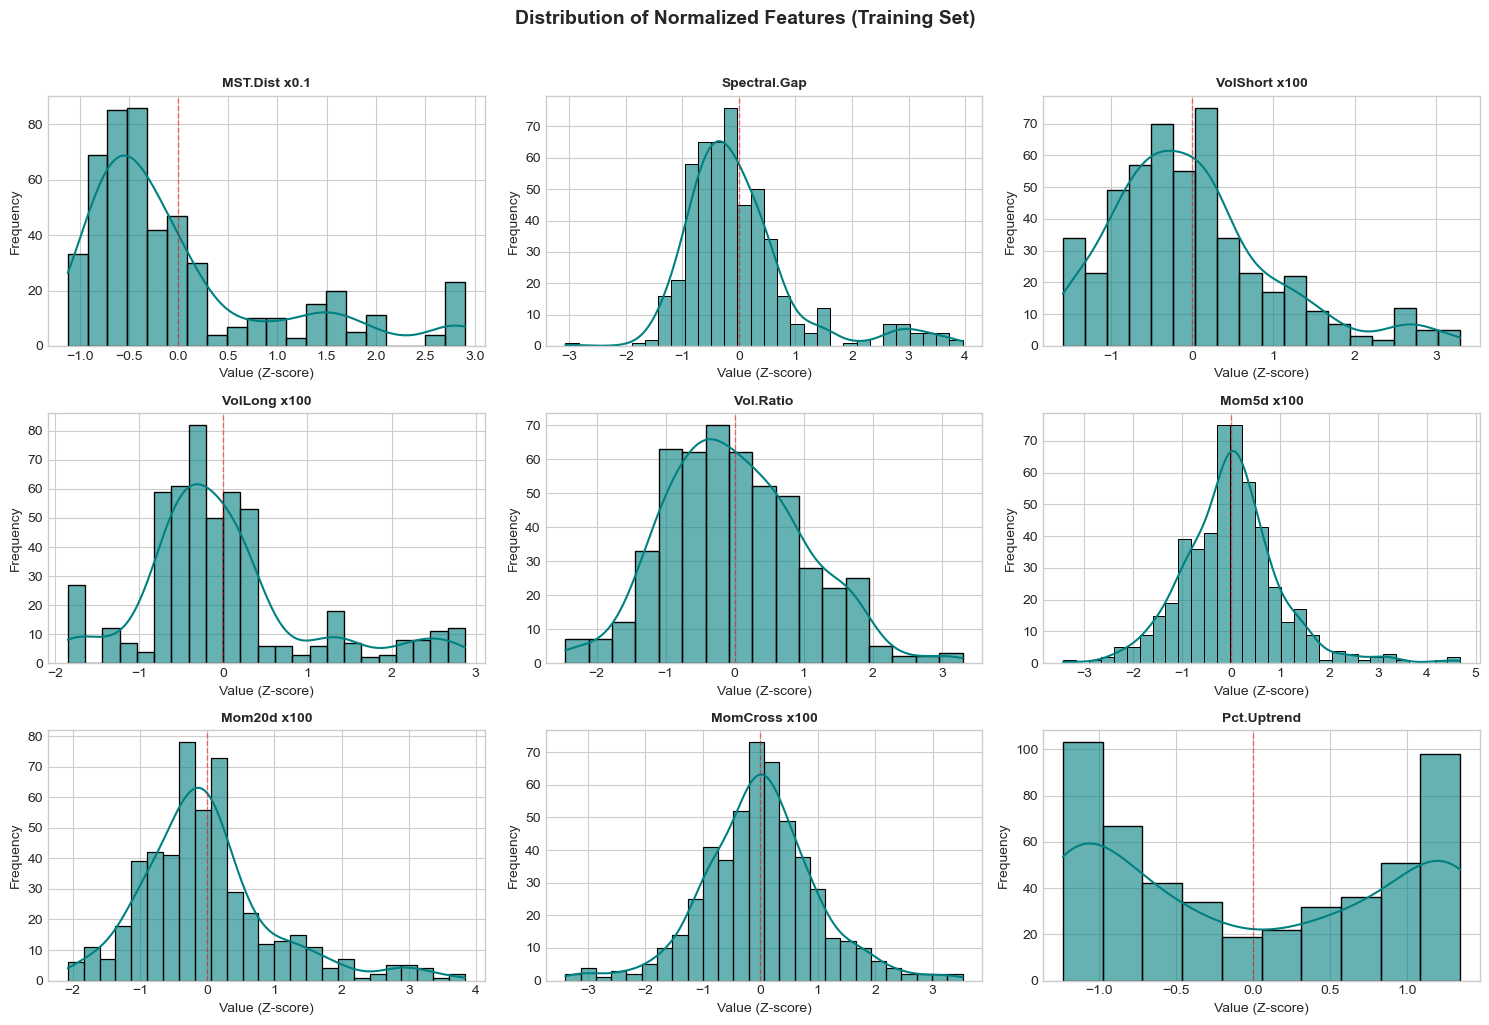

Summary Statistics (Normalized):


,mean,std,min,max
MST.Dist x0.1,-6.357829e-07,1.000994,-1.121371,2.901813
Spectral.Gap,-9.385366e-07,1.000994,-3.071687,3.956040
VolShort x100,-1.120189e-06,1.000993,-1.589430,3.297937
VolLong x100,-8.931236e-07,1.000994,-1.846012,2.872459
Vol.Ratio,-4.238553e-07,1.000994,-2.452231,3.298336
Mom5d x100,1.513769e-08,1.000993,-3.439487,4.682428
Mom20d x100,1.362392e-07,1.000994,-2.071388,3.835279
MomCross x100,-5.676633e-09,1.000994,-3.395267,3.522531
Pct.Uptrend,2.800472e-07,1.000995,-1.234854,1.342827


In [10]:
def plot_feature_distributions():
    norm_list = []
    # Menggunakan config yang mengaktifkan kedua jenis fitur
    dist_config = {'use_network': True, 'use_market': True}
    
    for i in range(SET_WINDOW, len(ret_train)):
        c = GLOBAL_CACHE[('train', i)]
        obs, _ = build_observation(None, dist_config, c['nw_feat_full'], c['corr_f'], c['mkt_feat_full'])
        norm_list.append(obs)
    
    df_norm = pd.DataFrame(norm_list, columns=FEATURE_NAMES)
    
    plt.figure(figsize=(15, 10))
    for i, col in enumerate(FEATURE_NAMES):
        plt.subplot(3, 3, i+1)
        sns.histplot(df_norm[col], kde=True, color='teal', alpha=0.6)
        plt.axvline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
        plt.title(f'{col}', fontsize=10, fontweight='bold')
        plt.xlabel('Value (Z-score)')
        plt.ylabel('Frequency')
    
    plt.suptitle('Distribution of Normalized Features (Training Set)', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    print("Summary Statistics (Normalized):")
    display(df_norm.describe().T[['mean', 'std', 'min', 'max']])

plot_feature_distributions()

## 9. RL Environment

In [11]:
class AblationPortfolioEnv(gym.Env):
    """
    Gymnasium environment untuk ablation study portfolio optimization.

    Action      : gamma scalar dalam [-5, 5].
    Observation : fitur (network + market) yang telah dinormalisasi.
    Reward      : risk-return metric (Sharpe/Sortino/Calmar/Ulcer),
                  dinormalisasi online Welford per episode.

    FIX:
    - Parameter split='train'/'test' menggantikan data_start_offset integer.
    - _rew_stats di-reset di reset() agar tidak ada bias akumulasi lintas episode.
    """

    def __init__(self, data, config, split='train'):
        super().__init__()
        self.data   = data
        self.config = config
        self.split  = split
        self.current_step    = SET_WINDOW
        self._returns_buffer = []
        self._reset_rew_stats()

        dim = get_obs_dim(config)
        self.action_space      = spaces.Box(low=-5.0, high=5.0, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(dim,), dtype=np.float32)

    def _reset_rew_stats(self):
        self._rew_stats = {'mean': 0.0, 'M2': 0.0, 'count': 0}

    def _get_obs(self):
        c = GLOBAL_CACHE[(self.split, self.current_step)]
        # [v4] Teruskan mkt_feat_full agar build_observation tidak menghitung ulang
        obs, _ = build_observation(c['win'], self.config, c['nw_feat_full'], c['corr_f'], c['mkt_feat_full'])
        return obs

    def reset(self, seed=None, options=None):
        self.current_step    = SET_WINDOW
        self._returns_buffer = []
        self._reset_rew_stats()  # FIX: reset per episode
        return self._get_obs(), {}

    def step(self, action):
        gamma = float(np.clip(action[0], -5.0, 5.0))
        c     = GLOBAL_CACHE[(self.split, self.current_step)]
        w     = fast_centrality_weights(c['cov_f'], c['cent_vec'], c['mu'], gamma)

        port_ret = np.dot(w, self.data.iloc[self.current_step].values)
        self._returns_buffer.append(port_ret)
        if len(self._returns_buffer) > REWARD_WINDOW:
            self._returns_buffer.pop(0)

        arr         = np.array(self._returns_buffer)
        reward_type = self.config.get('reward_type', 'calmar')

        if len(arr) < 2:
            raw_reward = port_ret * 100
        else:
            if reward_type == 'sharpe':
                raw_reward = float(np.clip(calculate_sharpe_ratio(arr),  -10.0, 10.0))
            elif reward_type == 'sortino':
                raw_reward = float(np.clip(calculate_sortino_ratio(arr), -10.0, 10.0))
            elif reward_type == 'calmar':
                raw_reward = float(np.clip(calculate_calmar_ratio(arr),  -10.0, 10.0))
            elif reward_type == 'ulcer':
                ann_ret = calculate_annualized_return(arr)
                ulcer   = calculate_ulcer_index(arr)
                raw_reward = float(np.clip(ann_ret / (ulcer + 1e-8), -10.0, 10.0))
            else:
                raw_reward = 0.0

        # Online Welford variance normalization (di-reset per episode)
        s = self._rew_stats
        s['count'] += 1
        delta      = raw_reward - s['mean']
        s['mean'] += delta / s['count']
        s['M2']   += delta * (raw_reward - s['mean'])
        std    = np.sqrt(s['M2'] / s['count']) if s['count'] > 1 else 1.0
        reward = float(np.clip(raw_reward / (std + 1e-6), -10.0, 10.0))

        self.current_step += 1
        done     = self.current_step >= len(self.data) - 1
        next_obs = (self._get_obs() if not done
                    else np.zeros(self.observation_space.shape, dtype=np.float32))
        return next_obs, reward, done, False, {}


## 10. Training

Menggunakan **`StepLoggerCallback`** (pengganti `RewardLoggerCallback`) yang mencatat mean reward dan rolling std setiap 500 steps. Data ini dipakai untuk `plot_convergence_analysis()` — tiga panel yang menjustifikasi bahwa 40 000 train steps sudah optimal:

1. **Panel 1** — mean reward ± std antar seed vs train steps, dengan garis vertikal auto-deteksi konvergensi.  
2. **Panel 2** — rolling std reward (proxy stabilitas policy): turun dan stabil setelah titik konvergensi.  
3. **Panel 3** — ΔReward per 2k-step interval (diminishing returns): mendekati nol di akhir training.

> *"Training dilakukan selama 40 000 timesteps mengikuti konvensi literatur portofolio RL (Carta et al., 2021; Ye et al., 2020). Konvergensi divalidasi melalui (1) stabilisasi rolling std reward, (2) konsistensi antar tiga random seed, dan (3) tidak adanya improvement signifikan pada interval step terakhir (diminishing returns → 0)."*


Experiments:   0%|          | 0/8 [00:00<?, ?it/s]

Seeds for E2_Sharpe:   0%|          | 0/1 [00:00<?, ?it/s]

Output()

Seeds for E2_Sortino:   0%|          | 0/1 [00:00<?, ?it/s]

Output()

Seeds for E2_Calmar:   0%|          | 0/1 [00:00<?, ?it/s]

Output()

Seeds for E2_Ulcer:   0%|          | 0/1 [00:00<?, ?it/s]

Output()

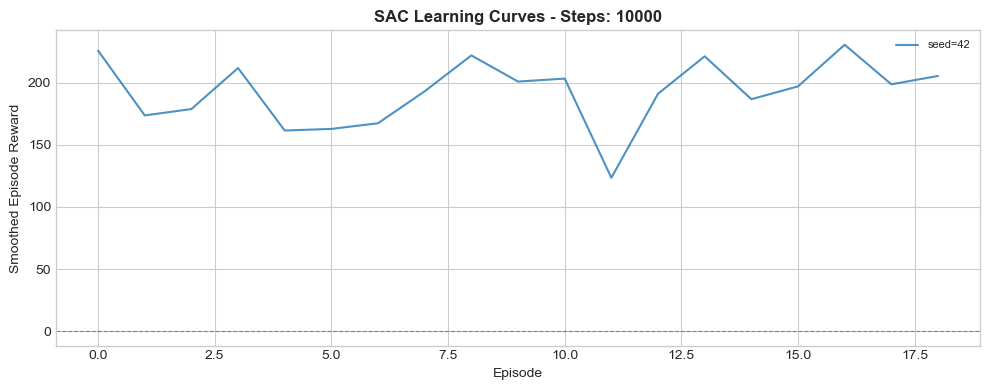

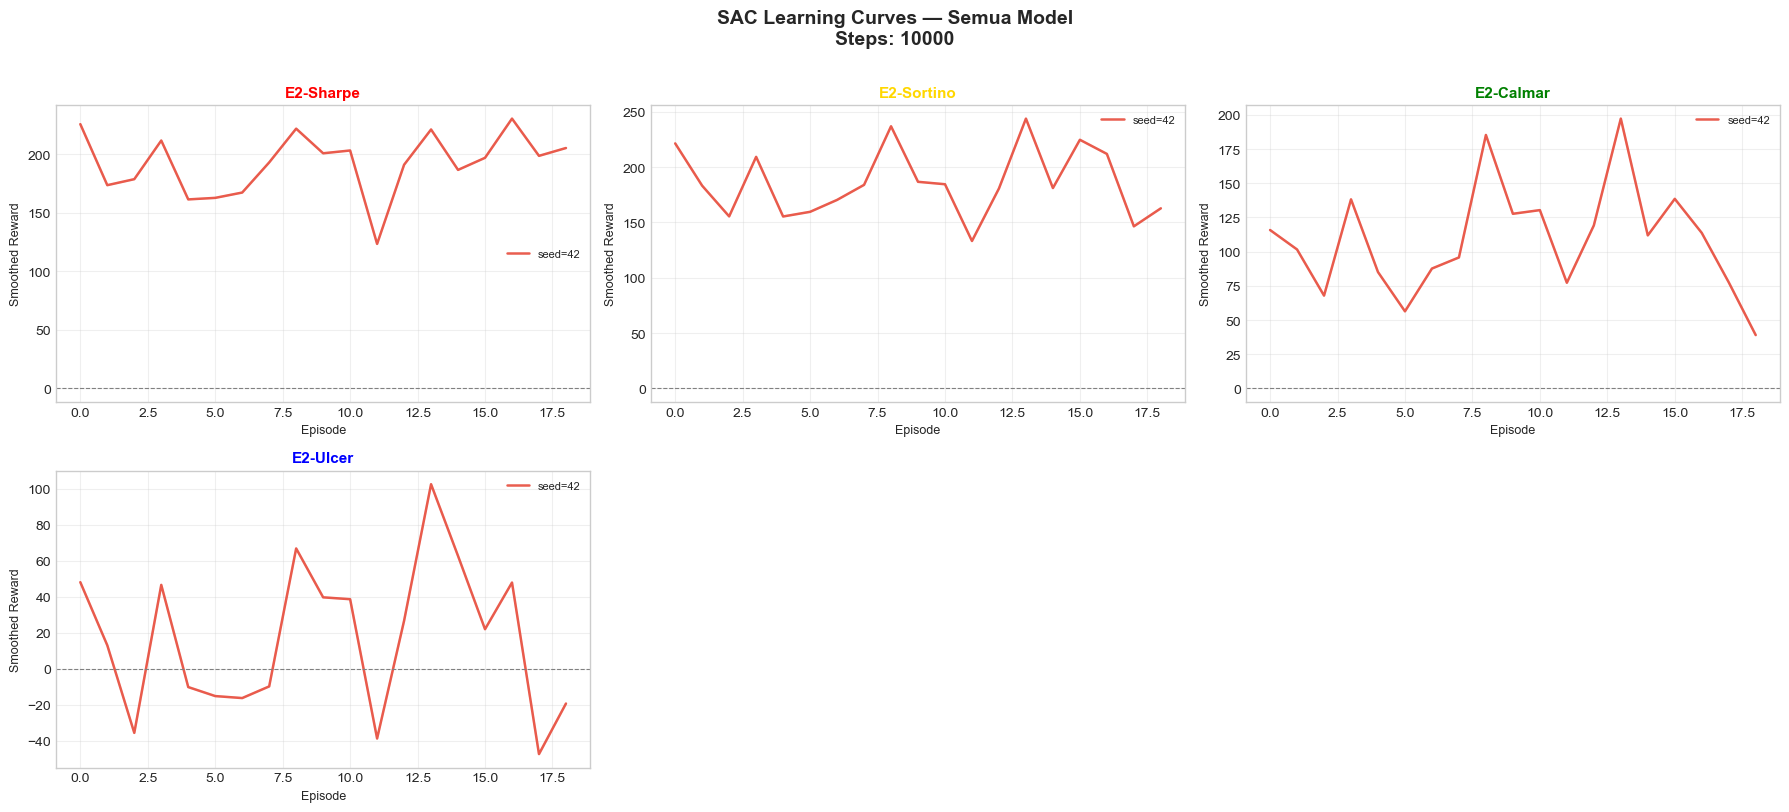

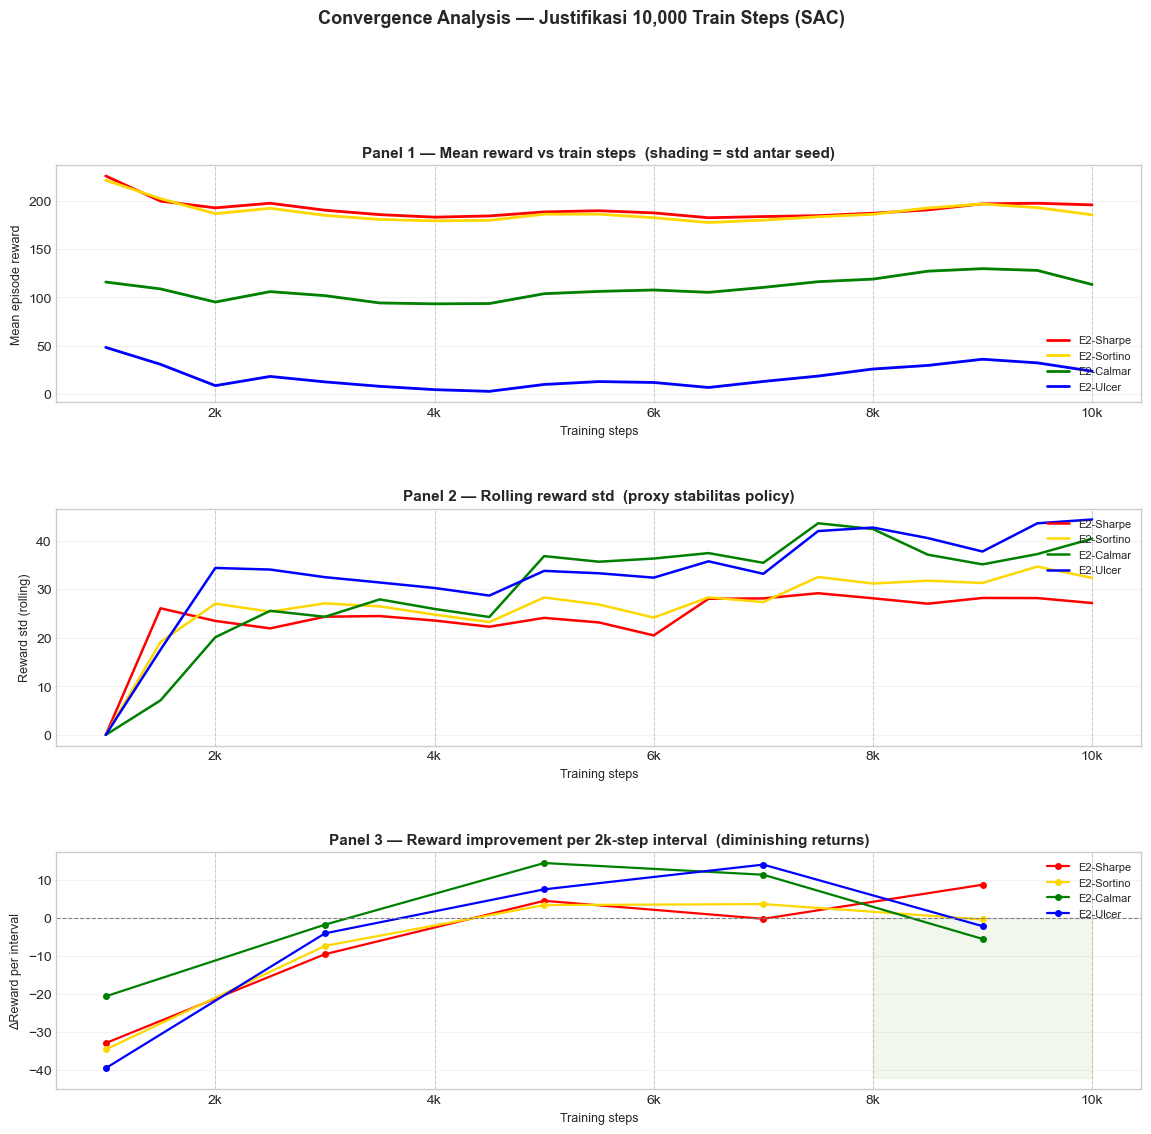


=== Ringkasan Konvergensi per Model ===
Training selesai.


In [12]:
trained_models      = {}
train_histories     = {}   # { exp_id: { seed: [episode_rewards] } }  (backward compat)
step_histories_cb   = {}   # { exp_id: { seed: StepLoggerCallback } }  (untuk convergence analysis)

exp_bar = tqdm(ABLATION_CONFIGS.items(), desc='Experiments')
for exp_id, config in exp_bar:
    # Skip static gamma, ensemble, buyhold, equal-weight (tidak ada RL training)
    if (config.get('static_gamma') is not None
            or config.get('is_ensemble')
            or config.get('is_buyhold')
            or config.get('is_equal_weight')):
        continue

    train_histories[exp_id]   = {}
    step_histories_cb[exp_id] = {}
    seed_bar = tqdm(SEEDS, desc=f'Seeds for {exp_id}', leave=False)

    for seed in seed_bar:
        name = f'model_{exp_id}_s{seed}'
        if os.path.exists(name + '.zip') and not FORCE_RETRAIN:
            trained_models[(exp_id, seed)] = name
            print(f'  Loaded existing: {name}')
            continue

        env      = AblationPortfolioEnv(ret_train, config, split='train')
        eval_env = AblationPortfolioEnv(ret_test,  config, split='test')

        # StepLoggerCallback menggantikan RewardLoggerCallback:
        #   log_freq=500  → satu titik data setiap 500 steps
        #   rolling_window=10 → std dihitung dari 10 episode terakhir
        step_cb   = StepLoggerCallback(log_freq=500, rolling_window=10)
        eval_cb   = EvalCallback(eval_env, eval_freq=2000,
                                 deterministic=True, verbose=0)

        model = SAC(
            'MlpPolicy', env,
            seed=seed,
            verbose=0,
            learning_rate=1e-4,
            buffer_size=50_000,
            batch_size=256,
            tau=0.005,
            gamma=0.99,
            ent_coef='auto',
            policy_kwargs=dict(net_arch=[128, 128])
        )
        model.learn(total_timesteps=TRAIN_STEPS,
                    callback=[step_cb, eval_cb],
                    progress_bar=True)

        model.save(name)
        trained_models[(exp_id, seed)]     = name
        train_histories[exp_id][seed]      = step_cb.episode_rewards   # backward compat
        step_histories_cb[exp_id][seed]    = step_cb                   # untuk convergence

# ── Plot legacy learning curves (episode-based) ──────────────────────
if 'E2_Sharpe' in train_histories:
    plot_learning_curves(train_histories['E2_Sharpe'])

plot_all_learning_curves(train_histories)

# ── Plot convergence analysis (step-based, 3 panel) ──────────────────
conv_steps = plot_convergence_analysis(step_histories_cb)

print('Training selesai.')


## 11. Backtesting Loop

In [13]:
results_test  = {}
results_train = {}

# ── NEW: dictionaries untuk feature impact analysis ─────────────────────
feature_log  = {}  # { exp_id: { 'test': { seed: np.ndarray [T x n_feat] }, 'train': ... } }
gamma_log    = {}  # { exp_id: { 'test': { seed: [gamma] },                  'train': ... } }
reward_log   = {}  # { exp_id: { 'test': { seed: [port_ret] },               'train': ... } }

all_exp_ids = list(ABLATION_CONFIGS.keys()) + ['Classic-MV']  # BuyHold_Markowitz sudah ada di ABLATION_CONFIGS

for exp_id in tqdm(all_exp_ids, desc='Backtesting'):
    results_test[exp_id]  = pd.DataFrame()
    results_train[exp_id] = pd.DataFrame()
    config = ABLATION_CONFIGS.get(exp_id, {})
    feature_log[exp_id]  = {'test': {}, 'train': {}}
    gamma_log[exp_id]    = {'test': {}, 'train': {}}
    reward_log[exp_id]   = {'test': {}, 'train': {}}

    for seed in SEEDS:
        model           = None
        ensemble_models = []

        if exp_id != 'Classic-MV' and config.get('static_gamma') is None and not config.get('is_buyhold') and not config.get('is_equal_weight'):
            if config.get('is_ensemble'):
                for m_id in ['E2_Sharpe', 'E2_Sortino', 'E2_Calmar', 'E2_Ulcer']:
                    ensemble_models.append(SAC.load(trained_models[(m_id, seed)]))
            else:
                model = SAC.load(trained_models[(exp_id, seed)])

        # ── Buy&Hold-Markowitz: hitung bobot awal sekali, lalu drift ──────────
        if config.get('is_buyhold'):
            def _make_buyhold_rets(data_df, split_key):
                """
                Bobot awal = Markowitz-Centrality dengan gamma=1 pada window pertama.
                Setelah itu bobot dibiarkan drift alami mengikuti harga (no rebalancing).
                Ini mensimulasikan investor yang menentukan alokasi awal menggunakan
                network-Markowitz, lalu tidak melakukan rebalancing sama sekali.
                """
                c0  = GLOBAL_CACHE[(split_key, SET_WINDOW)]
                w   = fast_centrality_weights(c0['cov_f'], c0['cent_vec'],
                                              c0['mu'], gamma=1.0)   # inisialisasi
                rets = []
                for idx in range(SET_WINDOW, len(data_df)):
                    r_vec    = data_df.iloc[idx].values
                    port_ret = float(np.dot(w, r_vec))
                    rets.append(port_ret)
                    # drift: biarkan bobot bergerak mengikuti return aset, tanpa rebalancing
                    w = w * (1 + r_vec)
                    total = w.sum()
                    if total > 1e-10:
                        w = w / total          # normalisasi nilai (bukan rebalancing)
                    else:
                        w = np.ones(len(w)) / len(w)  # fallback jika collapse
                return rets

            rets_test  = _make_buyhold_rets(ret_test,  'test')
            rets_train = _make_buyhold_rets(ret_train, 'train')
            results_test[exp_id][seed]  = pd.Series(rets_test,
                                                     index=ret_test.index[SET_WINDOW:])
            results_train[exp_id][seed] = pd.Series(rets_train,
                                                     index=ret_train.index[SET_WINDOW:])
            gamma_log[exp_id]['test'][seed]   = [1.0] * len(rets_test)
            gamma_log[exp_id]['train'][seed]  = [1.0] * len(rets_train)
            reward_log[exp_id]['test'][seed]  = rets_test
            reward_log[exp_id]['train'][seed] = rets_train
            continue   # skip sisa loop (tidak perlu get_weights)

        def get_weights_with_log(split, step_idx):
            """Kembalikan (weights, gamma_val, obs_array)."""
            c = GLOBAL_CACHE[(split, step_idx)]
            if exp_id == 'Classic-MV':
                return compute_classic_mv_weights(c['win']), None, None
            if config.get('is_equal_weight'):
                return (np.ones(len(assets)) / len(assets)), None, None
            if config.get('static_gamma') is not None:
                w = fast_centrality_weights(c['cov_f'], c['cent_vec'],
                                            c['mu'], config['static_gamma'])
                return w, config['static_gamma'], None
            obs, _ = build_observation(c['win'], config, c['nw_feat_full'], c['corr_f'], c['mkt_feat_full'])
            if config.get('is_ensemble'):
                gammas = [float(em.predict(obs, deterministic=True)[0][0])
                          for em in ensemble_models]
                gamma_val = float(np.mean(gammas))
            else:
                action, _ = model.predict(obs, deterministic=True)
                gamma_val = float(action[0])
            w = fast_centrality_weights(c['cov_f'], c['cent_vec'], c['mu'], gamma_val)
            return w, gamma_val, obs

        def _run_split(data_df, split_key):
            rets_list  = []
            gamma_list = []
            feat_list  = []
            for i in range(SET_WINDOW, len(data_df)):
                w, g, obs = get_weights_with_log(split_key, i)
                port_ret = float(np.dot(w, data_df.iloc[i].values))
                rets_list.append(port_ret)
                gamma_list.append(g)
                feat_list.append(obs)
            return rets_list, gamma_list, feat_list

        # --- Testing ---
        rets_test, gamma_test, feat_test = _run_split(ret_test, 'test')
        results_test[exp_id][seed] = pd.Series(
            rets_test, index=ret_test.index[SET_WINDOW:])
        gamma_log[exp_id]['test'][seed]   = gamma_test
        reward_log[exp_id]['test'][seed]  = rets_test
        if len(feat_test) > 0 and feat_test[0] is not None:
            feature_log[exp_id]['test'][seed] = np.array(feat_test)

        # --- Training (evaluasi ulang, bukan training) ---
        rets_tr, gamma_tr, feat_tr = _run_split(ret_train, 'train')
        results_train[exp_id][seed] = pd.Series(
            rets_tr, index=ret_train.index[SET_WINDOW:])
        gamma_log[exp_id]['train'][seed]   = gamma_tr
        reward_log[exp_id]['train'][seed]  = rets_tr
        if len(feat_tr) > 0 and feat_tr[0] is not None:
            feature_log[exp_id]['train'][seed] = np.array(feat_tr)

print('Backtesting selesai.')
logged = [eid for eid, v in feature_log.items() if any(len(s)>0 for s in v.get('test',{}).values())]
print(f'  Feature log tersedia untuk: {logged}')





Backtesting:   0%|          | 0/9 [00:00<?, ?it/s]

Backtesting selesai.
  Feature log tersedia untuk: ['E2_Sharpe', 'E2_Sortino', 'E2_Calmar', 'E2_Ulcer', 'E2_Ensemble_Avg']


## 12. Final Analysis, Wilcoxon Tests & SHAP


=== Generating Final Dashboards ===


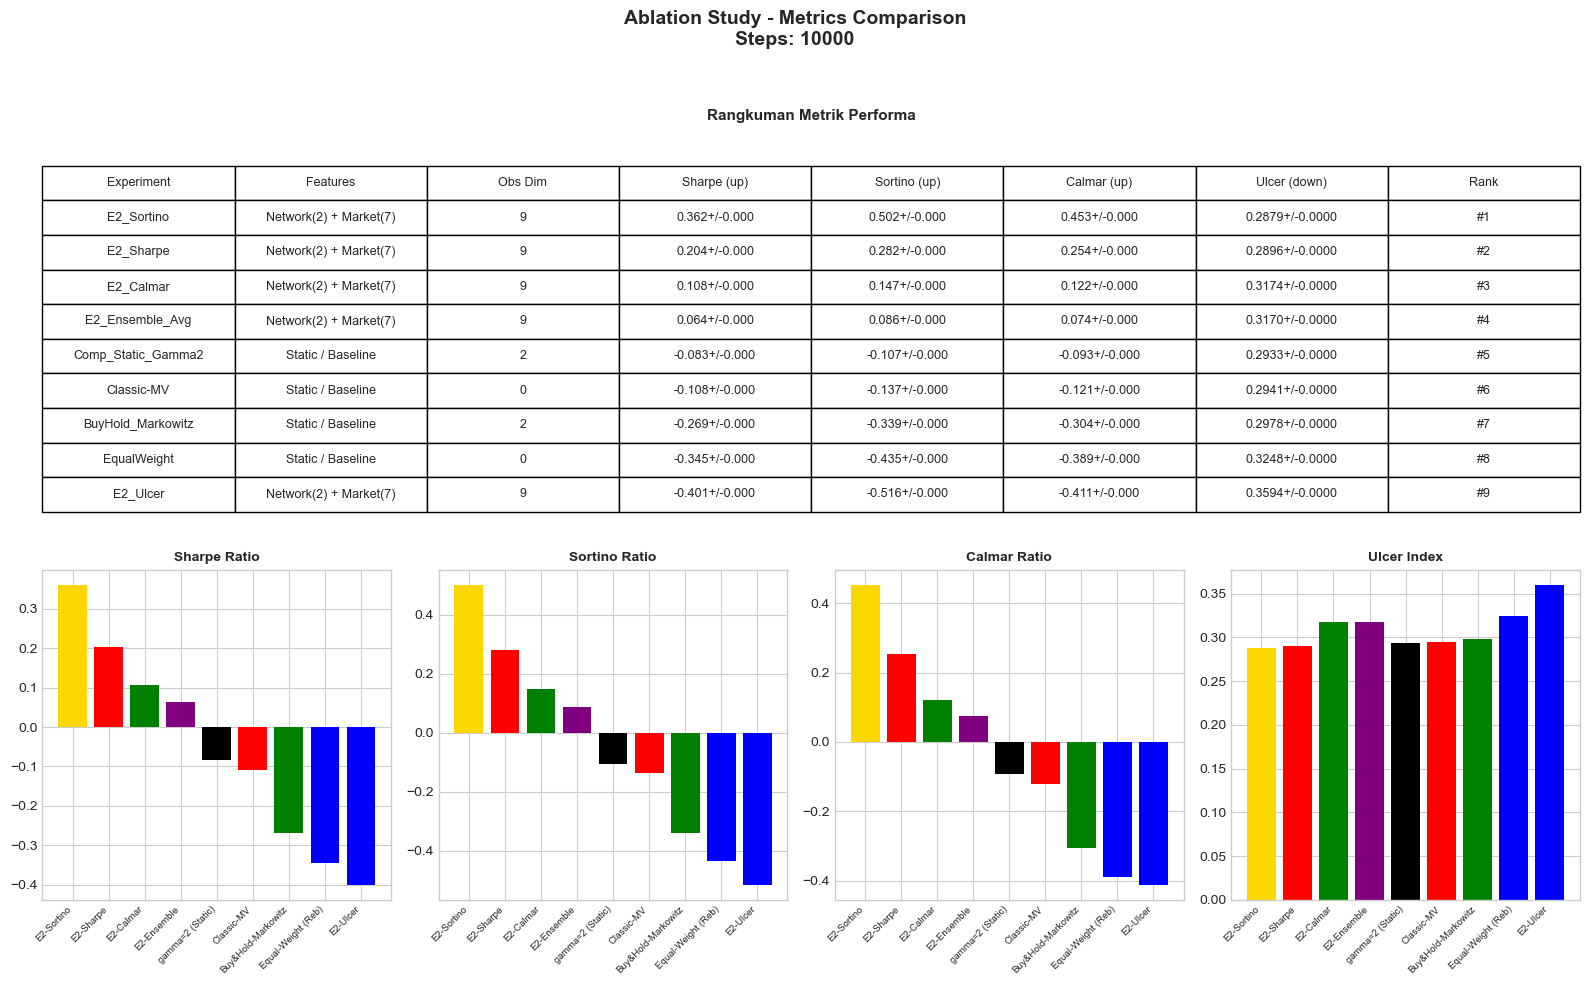

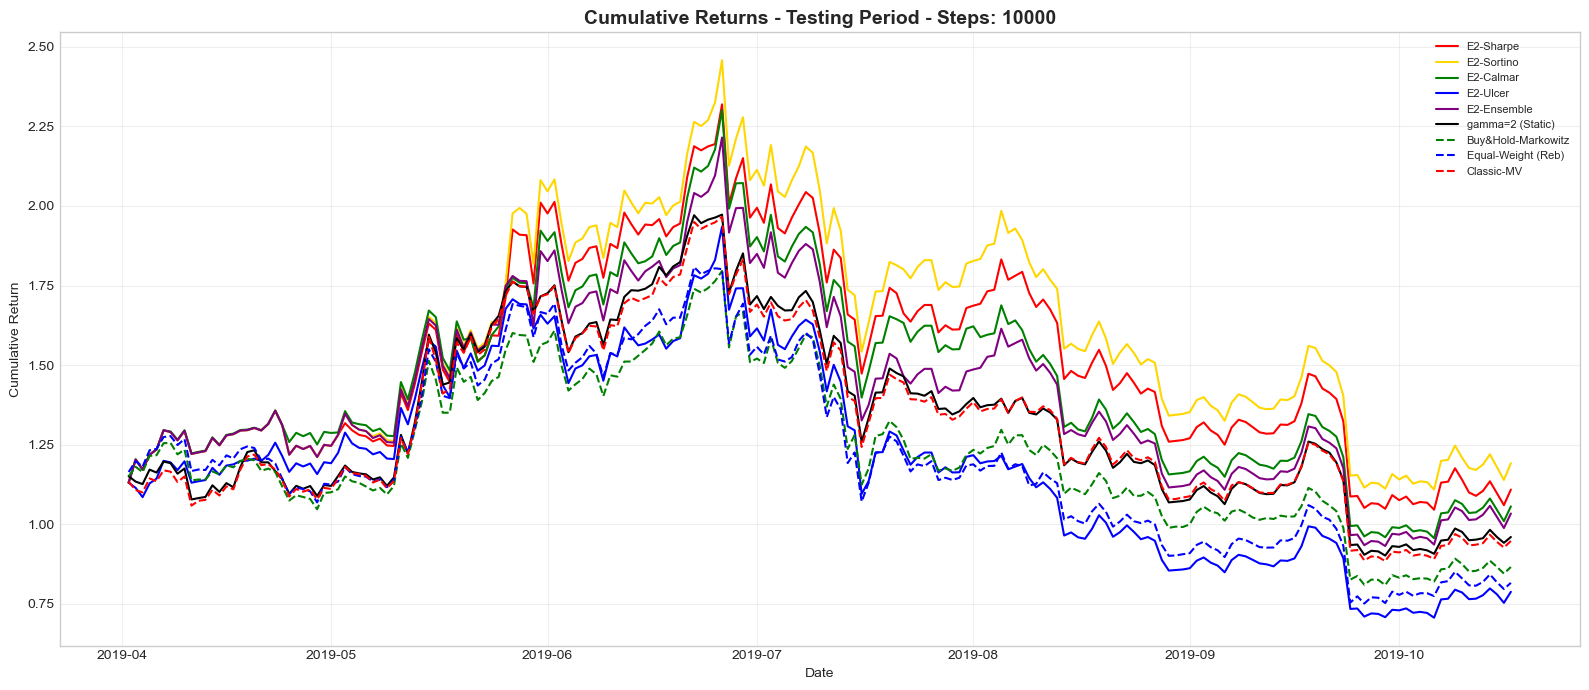

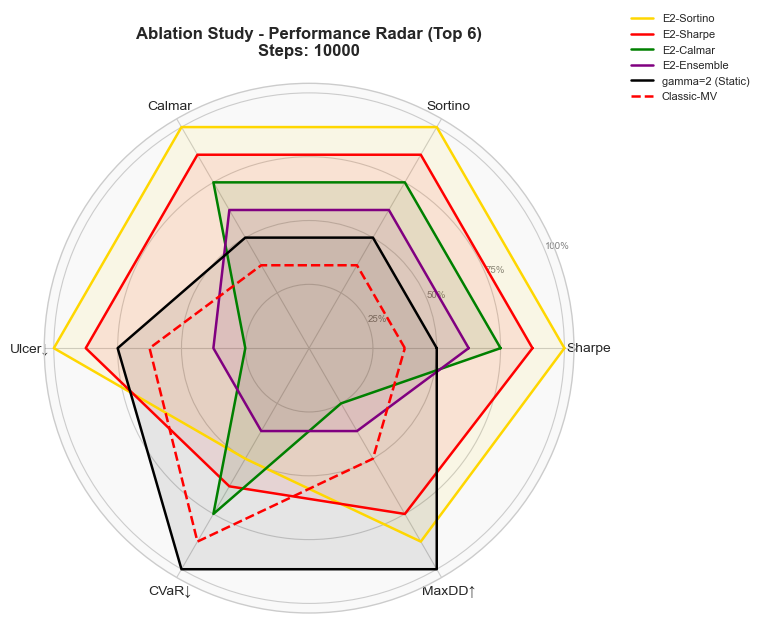

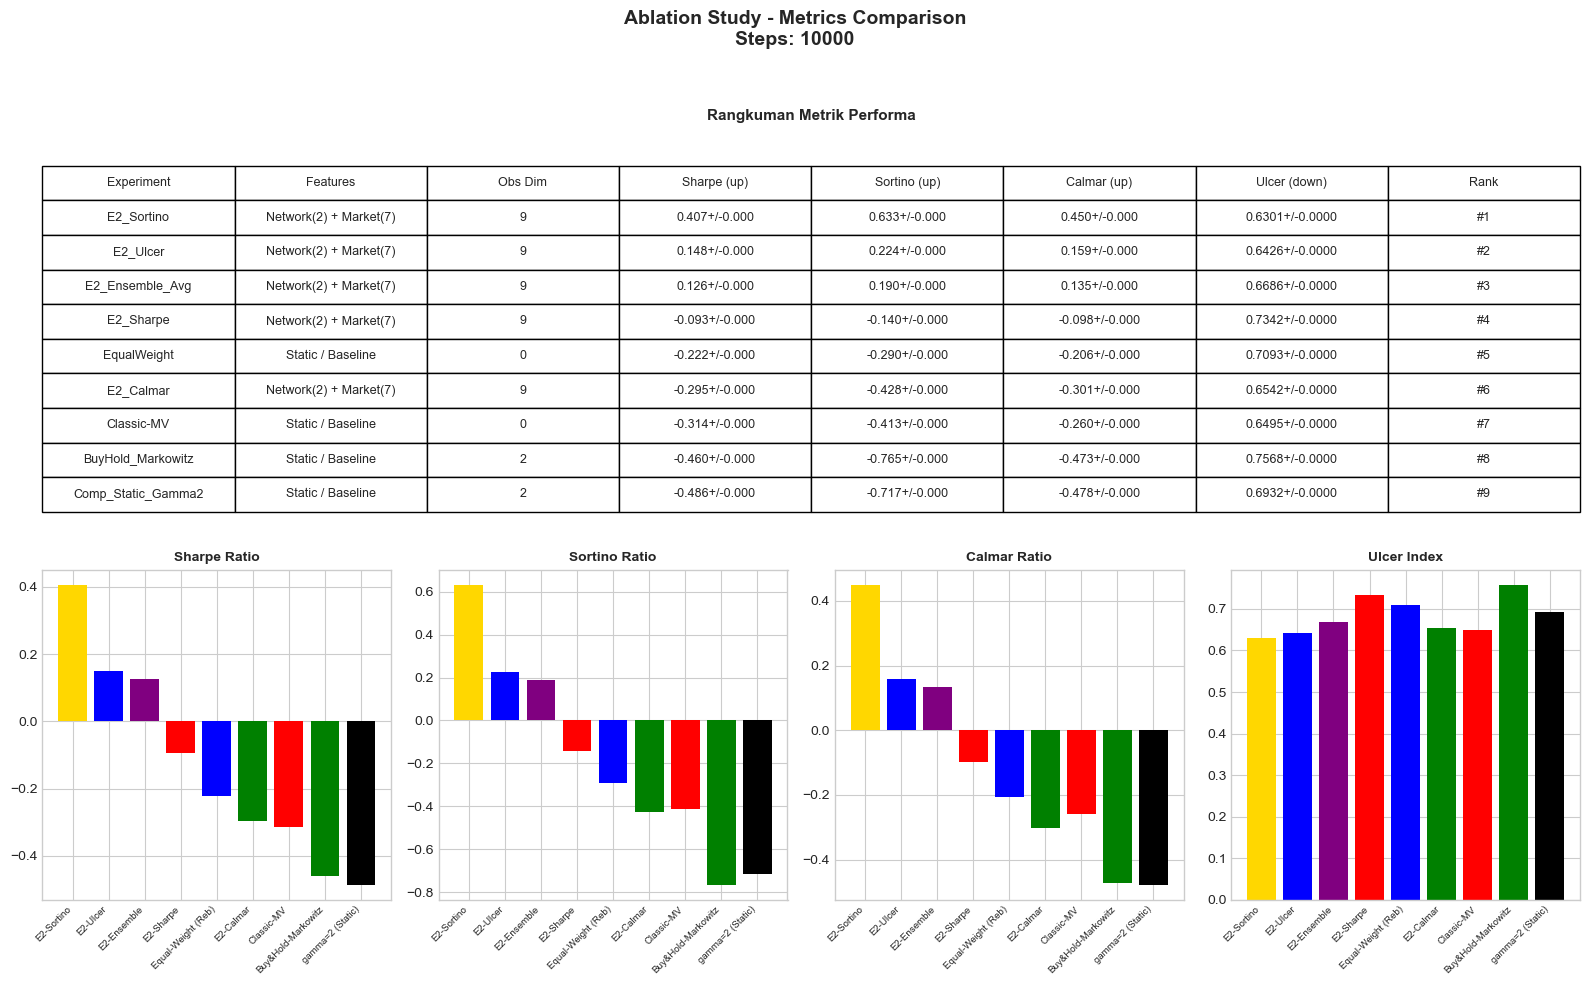

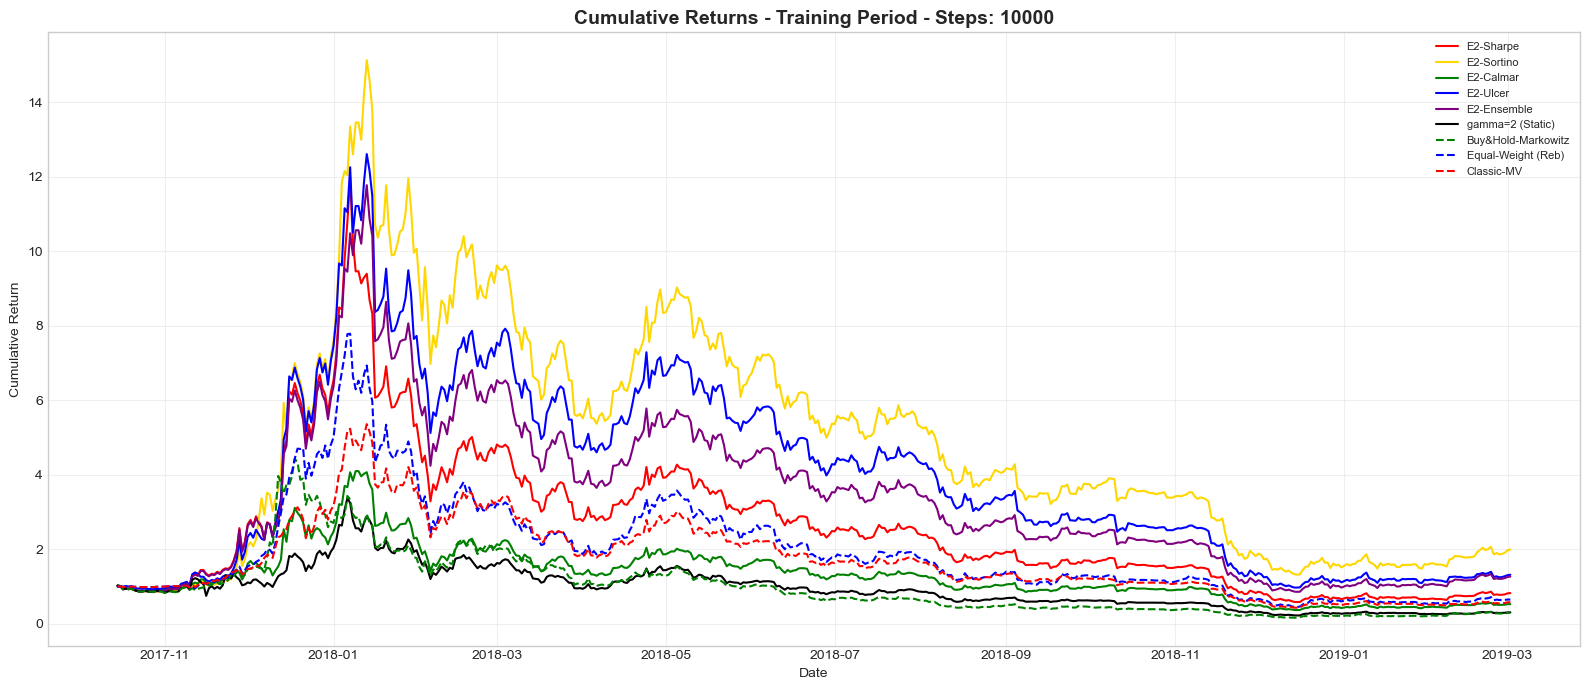

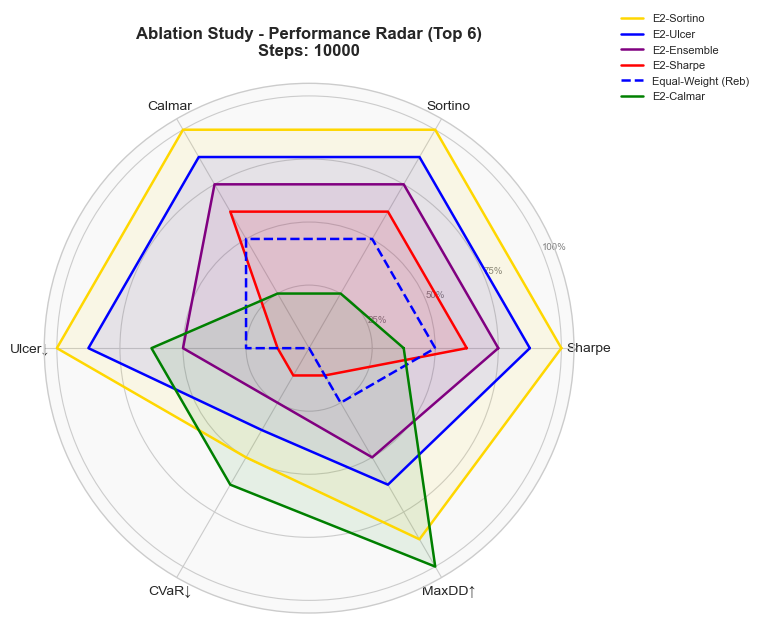


=== Wilcoxon Signed-Rank Tests (vs Classic-MV, Testing Period) ===
  E2_Sharpe             : p = 0.4842 
  E2_Sortino            : p = 0.9129 
  E2_Calmar             : p = 0.5601 
  E2_Ulcer              : p = 0.1286 
  E2_Ensemble_Avg       : p = 0.5251 
  Comp_Static_Gamma2    : p = 0.2601 
  BuyHold_Markowitz     : p = 0.5147 
  EqualWeight           : p = 0.2532 
  (* = signifikan pada alpha=0.05)

=== Generating SHAP Analysis ===
  Generating SHAP for E2_Sharpe...


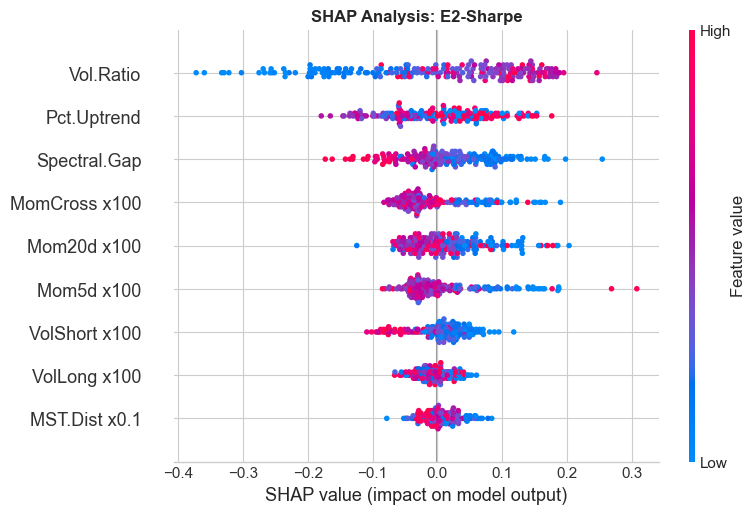

  Generating SHAP for E2_Sortino...


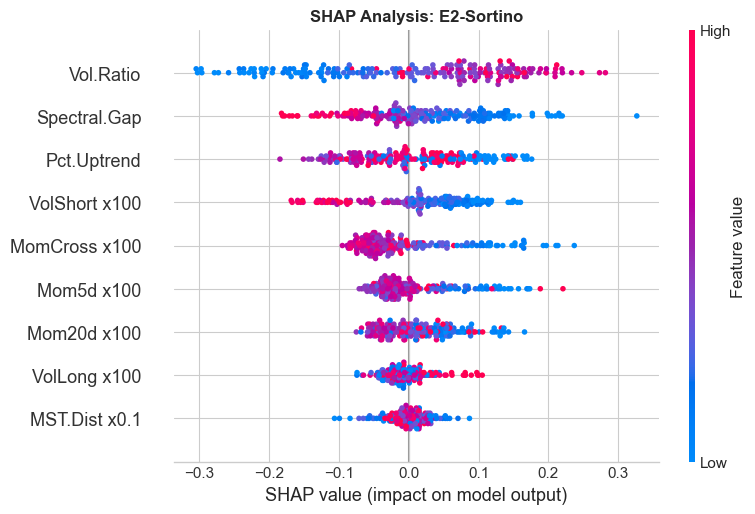

  Generating SHAP for E2_Calmar...


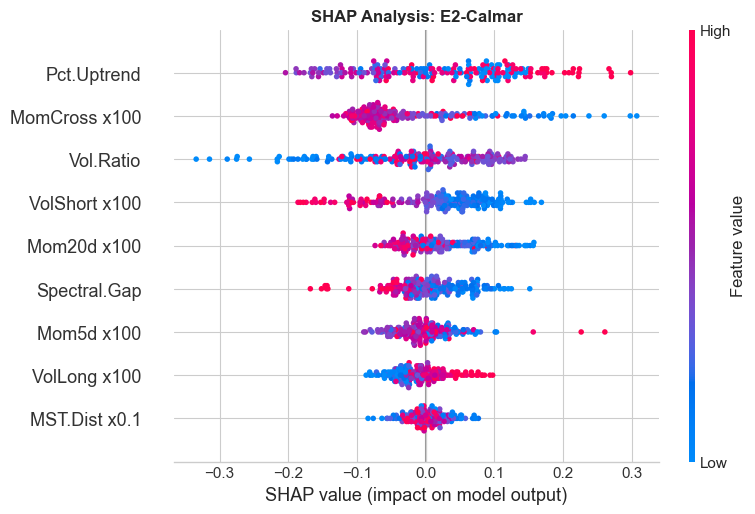

  Generating SHAP for E2_Ulcer...


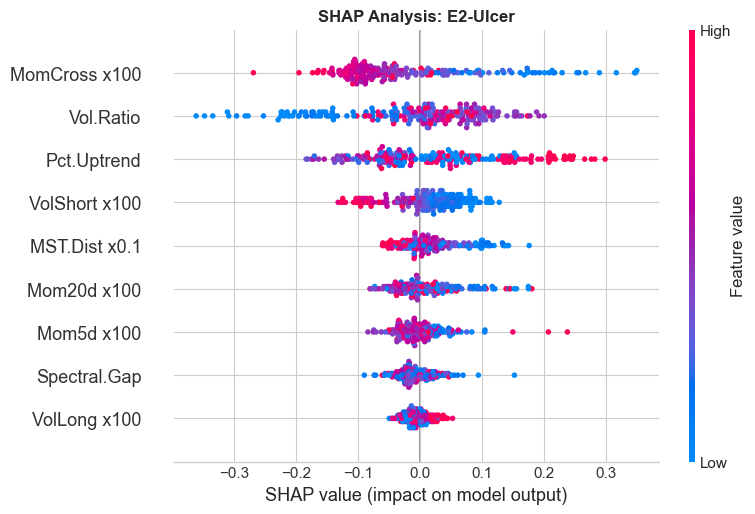

  Generating SHAP for E2_Ensemble_Avg...


ExactExplainer explainer: 201it [00:13,  4.00it/s]                         


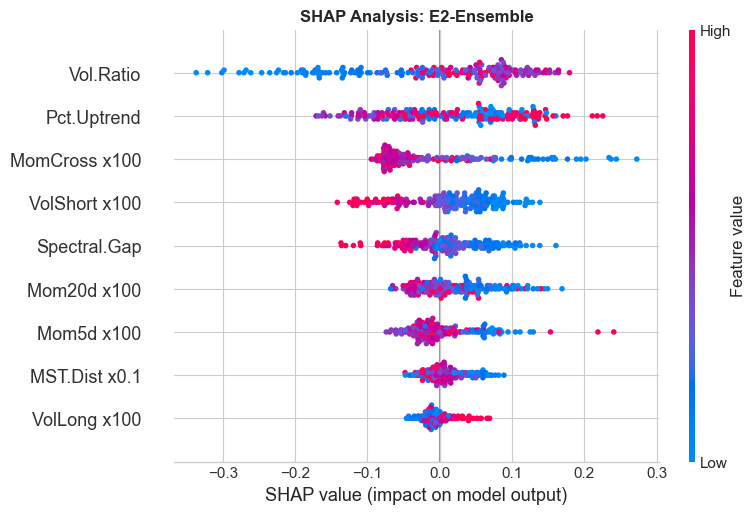


Analisis selesai.


In [14]:
print('\n=== Generating Final Dashboards ===')
generate_dashboard(results_test,  'Ablation Study', 'Testing',  'testing.png')
generate_dashboard(results_train, 'Ablation Study', 'Training', 'training.png')

# FIX: run_wilcoxon_tests sekarang benar-benar dipanggil + hasil ditampilkan
print('\n=== Wilcoxon Signed-Rank Tests (vs Classic-MV, Testing Period) ===')
pvals = run_wilcoxon_tests(results_test, baseline_id='Classic-MV')
for exp_id, p in pvals.items():
    sig = '*' if (not np.isnan(p) and p < STAT_ALPHA) else ''
    pstr = f'{p:.4f}' if not np.isnan(p) else 'NaN'
    print(f'  {exp_id:<22}: p = {pstr} {sig}')
print(f'  (* = signifikan pada alpha={STAT_ALPHA})')

print('\n=== Generating SHAP Analysis ===')
seed0 = SEEDS[0]
for exp_id in ['E2_Sharpe', 'E2_Sortino', 'E2_Calmar', 'E2_Ulcer', 'E2_Ensemble_Avg']:
    config = ABLATION_CONFIGS.get(exp_id, {})
    if exp_id == 'E2_Ensemble_Avg':
        m_paths = [trained_models.get((m, seed0))
                   for m in ['E2_Sharpe', 'E2_Sortino', 'E2_Calmar', 'E2_Ulcer']]
    else:
        m_paths = trained_models.get((exp_id, seed0))
    env_shap = AblationPortfolioEnv(ret_test, config, split='test')
    plot_shap_analysis(m_paths, env_shap, config, exp_id)

print('\nAnalisis selesai.')



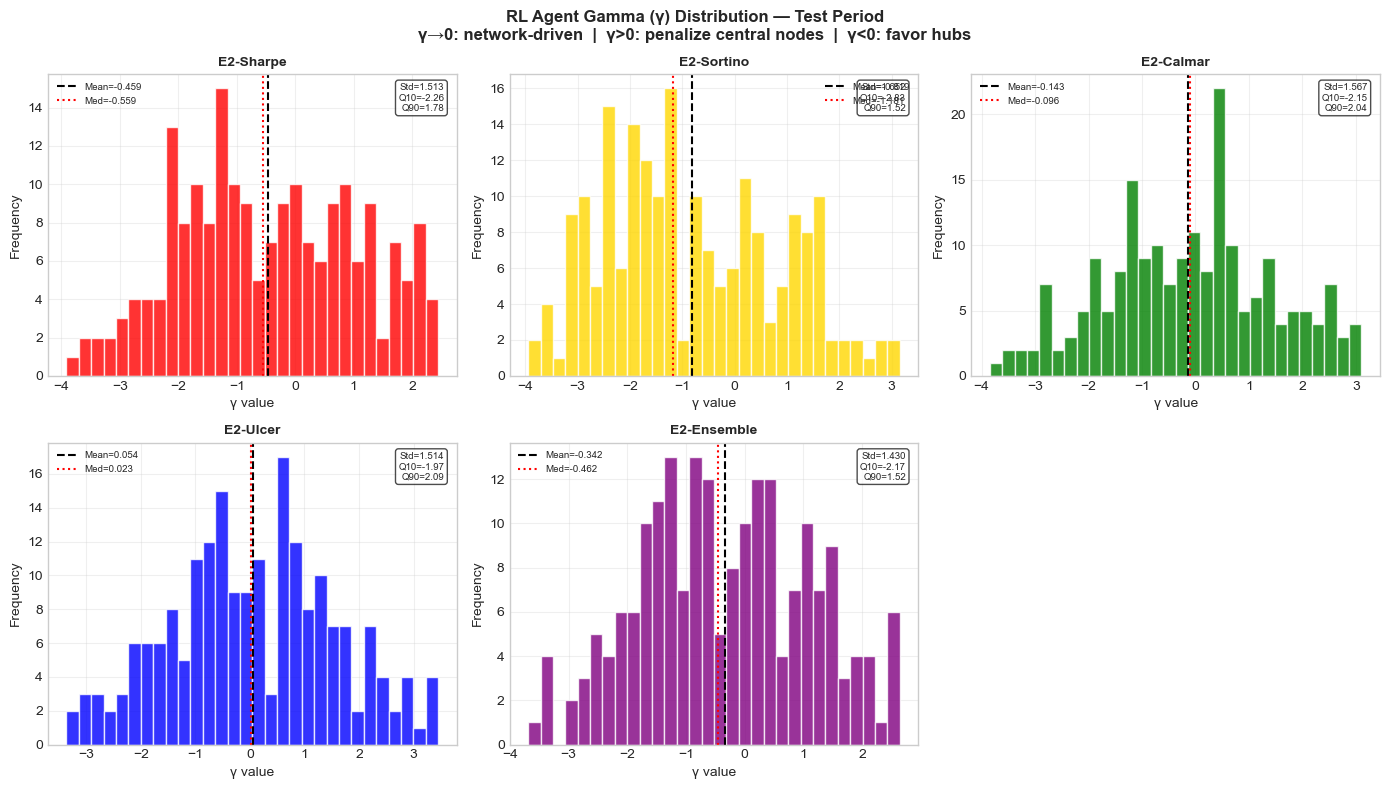

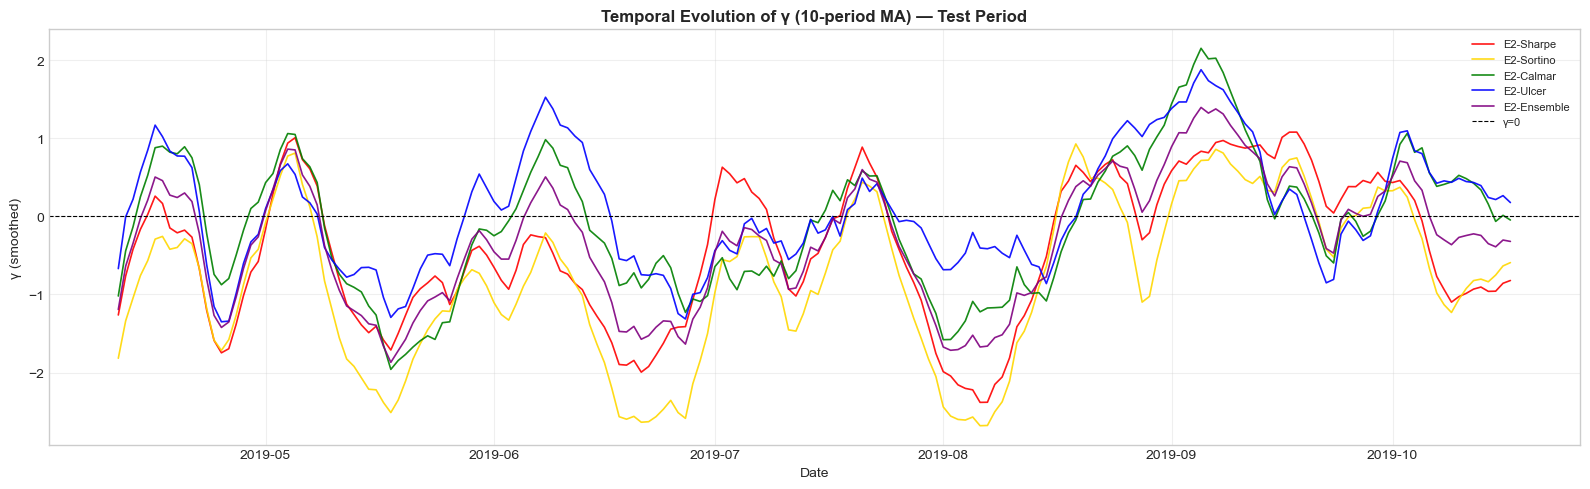

14C Gamma Distribution Analysis selesai.


In [15]:
# ═══════════════════════════════════════════════════════════════════════
# 14C. Gamma (Action) Distribution Analysis
# ═══════════════════════════════════════════════════════════════════════
# Visualisasi distribusi gamma yang dipilih RL agent selama test period.
# Menjawab: apakah agent belajar gamma yang stabil atau sangat fluktuatif?

rl_exp_ids = [eid for eid, cfg in ABLATION_CONFIGS.items()
              if cfg.get('static_gamma') is None and not cfg.get('is_buyhold') and not cfg.get('is_equal_weight')]

gamma_distributions = {}
for exp_id in rl_exp_ids:
    config = ABLATION_CONFIGS[exp_id]
    seed   = SEEDS[0]
    try:
        if config.get('is_ensemble'):
            # Load all sub-models
            sub_models = [SAC.load(trained_models[(m, seed)])
                          for m in ['E2_Sharpe', 'E2_Sortino', 'E2_Calmar', 'E2_Ulcer']]
            gammas = []
            for i in range(SET_WINDOW, len(ret_test)):
                c = GLOBAL_CACHE.get(('test', i))
                if c is None: continue
                obs, _ = build_observation(c['win'], config, c['nw_feat_full'], c['corr_f'], c['mkt_feat_full'])
                # Average actions from all sub-models
                sub_acts = [float(sm.predict(obs, deterministic=True)[0][0]) for sm in sub_models]
                gammas.append(np.mean(sub_acts))
        else:
            model = SAC.load(trained_models[(exp_id, seed)])
            gammas = []
            for i in range(SET_WINDOW, len(ret_test)):
                c = GLOBAL_CACHE.get(('test', i))
                if c is None: continue
                obs, _ = build_observation(c['win'], config, c['nw_feat_full'], c['corr_f'], c['mkt_feat_full'])
                action, _ = model.predict(obs, deterministic=True)
                gammas.append(float(action[0]))
        gamma_distributions[exp_id] = np.array(gammas)
    except Exception as ex:
        print(f'  Skip {exp_id}: {ex}')

if gamma_distributions:
    n_plots = len(gamma_distributions)
    fig, axes = plt.subplots(2, (n_plots+1)//2, figsize=(14, 8), facecolor='white')
    axes = axes.flatten()
    fig.suptitle('RL Agent Gamma (γ) Distribution — Test Period\n'
                 'γ→0: network-driven  |  γ>0: penalize central nodes  |  γ<0: favor hubs',
                 fontsize=12, fontweight='bold')

    for ax, (exp_id, gammas) in zip(axes, gamma_distributions.items()):
        color = ABLATION_COLORS.get(exp_id, '#777777')
        ax.hist(gammas, bins=30, color=color, alpha=0.8, edgecolor='white')
        ax.axvline(gammas.mean(),  color='black', linestyle='--', linewidth=1.5,
                   label=f'Mean={gammas.mean():.3f}')
        ax.axvline(np.median(gammas), color='red', linestyle=':', linewidth=1.5,
                   label=f'Med={np.median(gammas):.3f}')
        ax.set_title(get_display_name(exp_id), fontsize=10, fontweight='bold')
        ax.set_xlabel('γ value'); ax.set_ylabel('Frequency')
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

        # Annotate stats
        stats_txt = (f'Std={gammas.std():.3f}\n'
                     f'Q10={np.percentile(gammas,10):.2f}\n'
                     f'Q90={np.percentile(gammas,90):.2f}')
        ax.text(0.97, 0.97, stats_txt, transform=ax.transAxes,
                fontsize=7, va='top', ha='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

    for ax in axes[len(gamma_distributions):]:
        ax.set_visible(False)
    plt.tight_layout()
    if SAVE_IMAGES:
        plt.savefig(os.path.join(OUTPUT_DIR, '14C_gamma_distributions.png'), dpi=200)
    plt.show()
    plt.close()

    # ── Temporal gamma plot (time series of gamma choices) ─────────────────
    fig, ax = plt.subplots(figsize=(16, 5), facecolor='white')
    for exp_id, gammas in gamma_distributions.items():
        idx = ret_test.index[SET_WINDOW:SET_WINDOW+len(gammas)]
        ax.plot(idx, pd.Series(gammas, index=idx).rolling(10).mean(),
                label=get_display_name(exp_id),
                color=ABLATION_COLORS.get(exp_id, '#777777'), alpha=0.9, linewidth=1.2)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', label='γ=0')
    ax.set_title('Temporal Evolution of γ (10-period MA) — Test Period',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Date'); ax.set_ylabel('γ (smoothed)')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    if SAVE_IMAGES:
        plt.savefig(os.path.join(OUTPUT_DIR, '14C_gamma_temporal.png'), dpi=200)
    plt.show()
    plt.close()
print('14C Gamma Distribution Analysis selesai.')

## 15. Asset Composition Analysis — E2 Ensemble

Visualisasi komposisi aset yang dihasilkan model **E2_Ensemble_Avg** selama test period:
- **Plot A**: Stacked area chart — evolusi alokasi tiap aset dari waktu ke waktu
- **Plot B**: Box plot — distribusi bobot per aset (vs equal-weight baseline)
- **Plot C**: Pie chart — komposisi rata-rata keseluruhan test period
- **Plot D**: Heatmap — bobot mingguan (tanggal × aset)

  Steps collected : 199
  Assets          : ['BCH', 'BNB', 'BTC', 'EOS', 'ETH', 'LTC', 'TRX', 'XLM', 'XRP']
  Avg gamma (test): -0.3419

Average Portfolio Weights (E2-Ensemble):
  ETH         : 24.89%
  BTC         : 20.21%
  BNB         : 13.26%
  EOS         : 12.08%
  XRP         : 8.07%
  BCH         : 7.04%
  LTC         : 6.04%
  XLM         : 5.54%
  TRX         : 2.88%


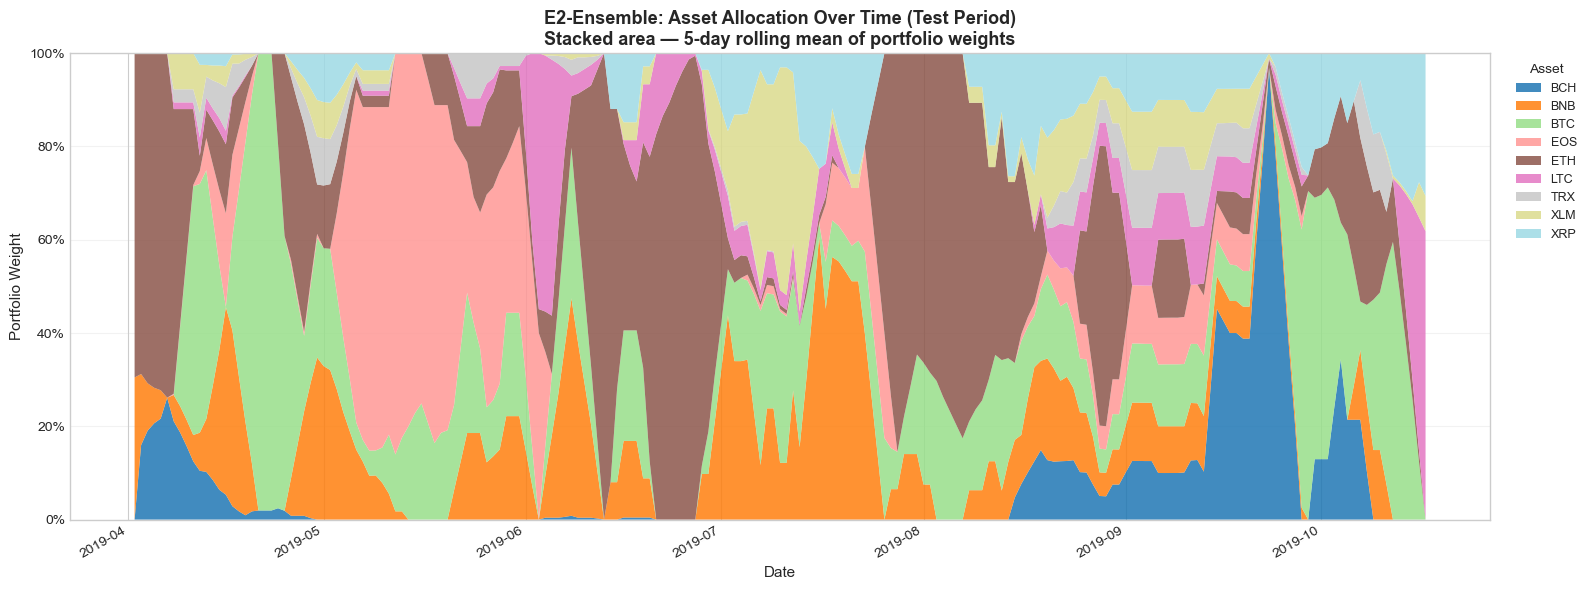

Plot A (Stacked Area) selesai.


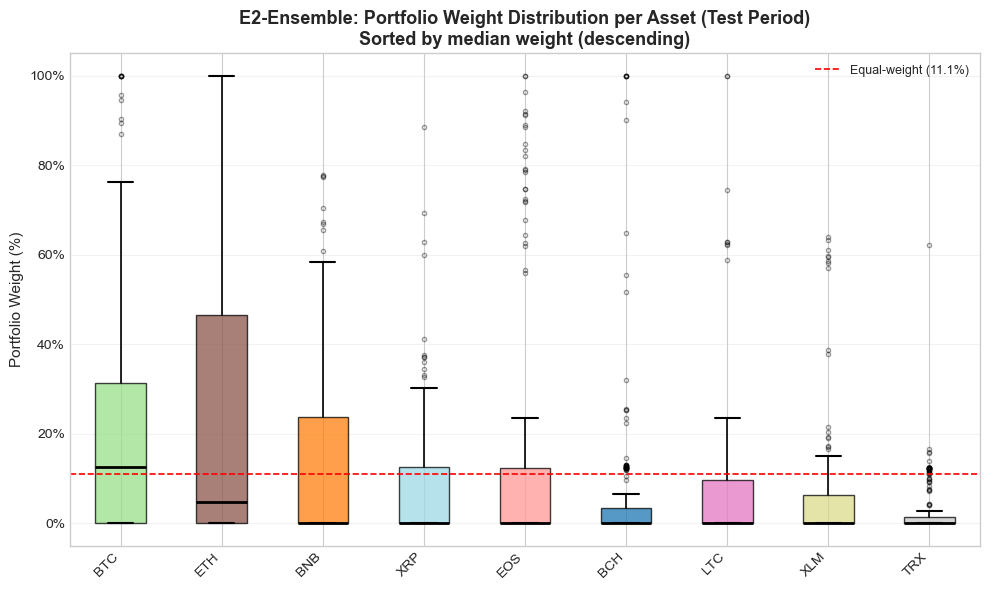

Plot B (Box Plot) selesai.


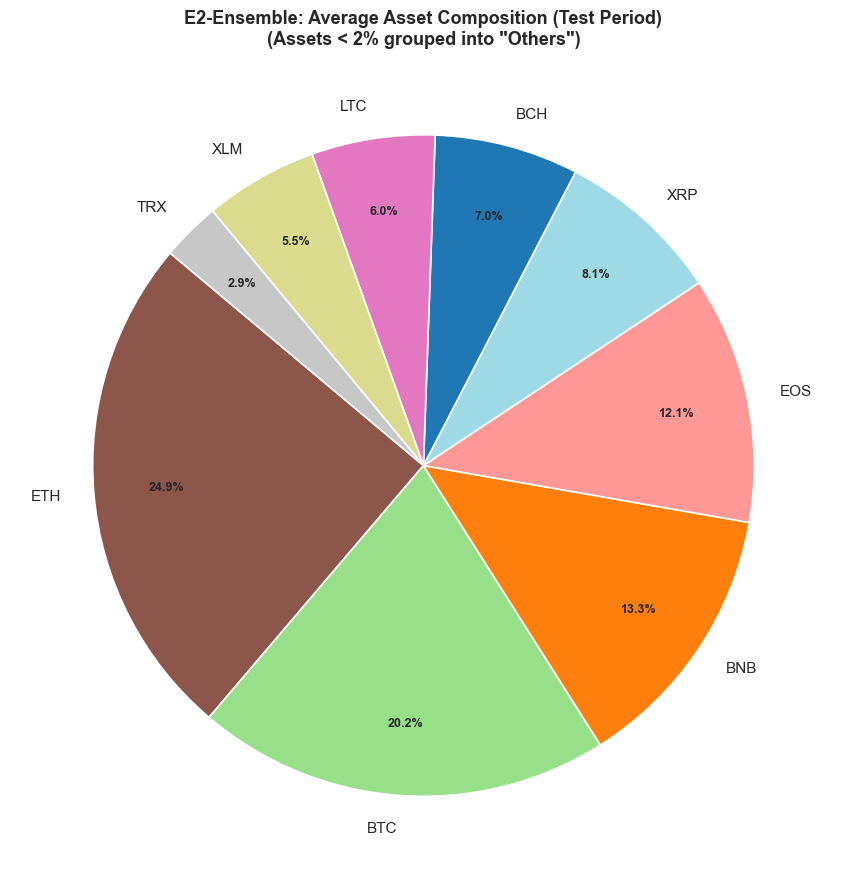

Plot C (Pie Chart) selesai.


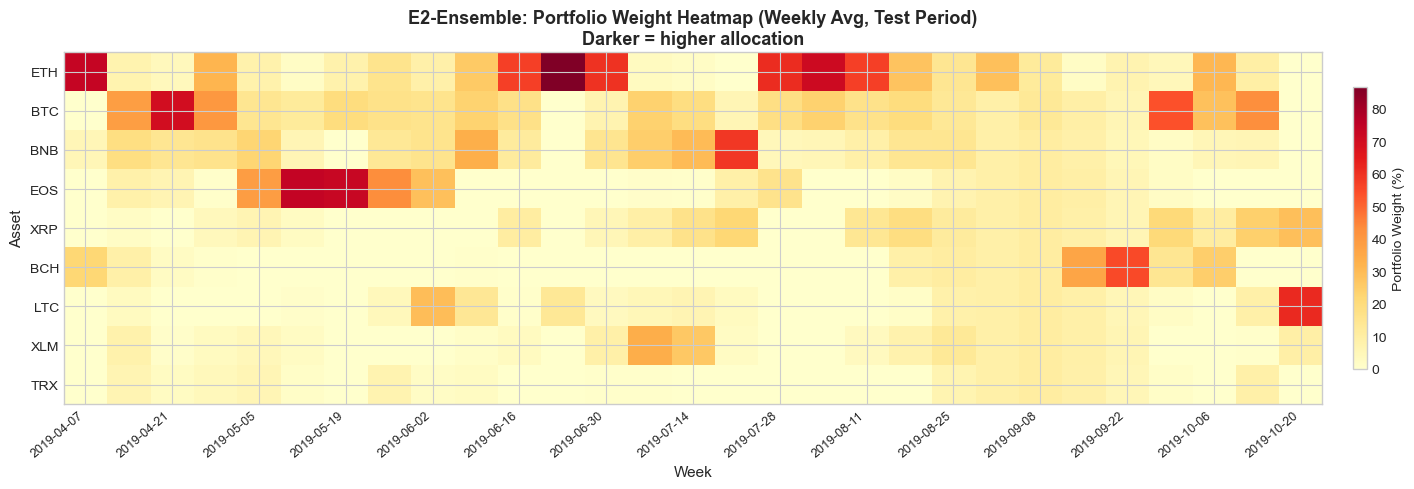

Plot D (Heatmap) selesai.

=== Summary: E2-Ensemble Asset Composition (Test Period) ===


,Mean (%),Median (%),Std (%),Min (%),Max (%)
ETH,24.89,4.75,35.44,0.0,100.00
BTC,20.21,12.55,26.33,0.0,100.00
BNB,13.26,0.00,20.03,0.0,77.91
EOS,12.08,0.00,26.24,0.0,100.00
XRP,8.07,0.00,13.72,0.0,88.61
BCH,7.04,0.00,19.54,0.0,100.00
LTC,6.04,0.00,15.10,0.0,100.00
XLM,5.54,0.00,12.91,0.0,63.94
TRX,2.88,0.00,6.38,0.0,62.09



Asset Composition Analysis selesai.


In [16]:
# ═══════════════════════════════════════════════════════════════════════
# 15. Asset Composition Analysis — E2 Ensemble Model
# ═══════════════════════════════════════════════════════════════════════
# Visualisasi komposisi aset (portfolio weights) yang dihasilkan oleh
# model E2_Ensemble_Avg selama test period.
#
# Plot yang dihasilkan:
#   A) Time-series stacked area chart → evolusi bobot tiap aset
#   B) Box plot                       → distribusi bobot per aset
#   C) Average pie chart              → komposisi rata-rata
#   D) Heatmap                        → bobot harian (tanggal × aset)
# ═══════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.cm as cm
import numpy as np
import pandas as pd

# ── 1. Collect per-step weights from E2_Ensemble_Avg ─────────────────
exp_id  = 'E2_Ensemble_Avg'
config  = ABLATION_CONFIGS[exp_id]
seed    = SEEDS[0]

print(f"Collecting portfolio weights for {exp_id} (seed={seed}) ...")

# Load the 4 sub-models that form the ensemble
sub_model_ids = ['E2_Sharpe', 'E2_Sortino', 'E2_Calmar', 'E2_Ulcer']
sub_models_e2 = []
for m_id in sub_model_ids:
    key = (m_id, seed)
    if key in trained_models:
        sub_models_e2.append(SAC.load(trained_models[key]))
    else:
        print(f"  WARNING: model {m_id} seed={seed} not found — skipping")

if len(sub_models_e2) == 0:
    print("ERROR: Tidak ada sub-model yang tersedia. Jalankan training terlebih dahulu.")
else:
    weight_records = []          # list of (date, weights_array)
    gamma_trace    = []          # untuk cross-check dengan 14C

    for i in range(SET_WINDOW, len(ret_test)):
        c = GLOBAL_CACHE.get(('test', i))
        if c is None:
            continue

        obs, _ = build_observation(
            c['win'], config,
            c['nw_feat_full'], c['corr_f'], c['mkt_feat_full']
        )

        # Ensemble: rata-rata gamma dari semua sub-model
        gammas_i = [float(sm.predict(obs, deterministic=True)[0][0]) for sm in sub_models_e2]
        gamma_avg = float(np.mean(gammas_i))
        gamma_trace.append(gamma_avg)

        # Hitung bobot portofolio dengan gamma rata-rata
        w = fast_centrality_weights(c['cov_f'], c['cent_vec'], c['mu'], gamma_avg)
        weight_records.append((ret_test.index[i], w))

    # Build DataFrame
    dates   = [r[0] for r in weight_records]
    weights = np.array([r[1] for r in weight_records])
    df_weights = pd.DataFrame(weights, index=dates, columns=assets)

    print(f"  Steps collected : {len(df_weights)}")
    print(f"  Assets          : {assets}")
    print(f"  Avg gamma (test): {np.mean(gamma_trace):.4f}")
    print("\nAverage Portfolio Weights (E2-Ensemble):")
    avg_w = df_weights.mean()
    for a, w_val in avg_w.sort_values(ascending=False).items():
        print(f"  {a:<12}: {w_val*100:.2f}%")

    # ─────────────────────────────────────────────────────────────────
    # ── PLOT A: Stacked Area Chart — Evolusi Bobot Aset (Time Series) ──
    # ─────────────────────────────────────────────────────────────────
    N_ASSETS = len(assets)
    cmap_area = cm.get_cmap('tab20', N_ASSETS)
    asset_colors = [cmap_area(i) for i in range(N_ASSETS)]

    # Rolling mean untuk memperhalus visualisasi (window 5 hari)
    df_smooth = df_weights.rolling(window=5, min_periods=1).mean()

    fig, ax = plt.subplots(figsize=(16, 6), facecolor='white')
    ax.stackplot(df_smooth.index,
                 [df_smooth[a].values for a in assets],
                 labels=assets,
                 colors=asset_colors,
                 alpha=0.85)
    ax.set_title(
        'E2-Ensemble: Asset Allocation Over Time (Test Period)\n'
        'Stacked area — 5-day rolling mean of portfolio weights',
        fontsize=13, fontweight='bold'
    )
    ax.set_xlabel('Date', fontsize=11)
    ax.set_ylabel('Portfolio Weight', fontsize=11)
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.0f}%'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    plt.xticks(rotation=30, ha='right')
    ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=9,
              title='Asset', title_fontsize=10, framealpha=0.9)
    ax.grid(True, alpha=0.25, axis='y')
    plt.tight_layout()
    if SAVE_IMAGES:
        plt.savefig(os.path.join(OUTPUT_DIR, '15A_e2_ensemble_weights_area.png'), dpi=200, bbox_inches='tight')
    plt.show()
    plt.close()
    print("Plot A (Stacked Area) selesai.")

    # ─────────────────────────────────────────────────────────────────
    # ── PLOT B: Box Plot — Distribusi Bobot per Aset ─────────────────
    # ─────────────────────────────────────────────────────────────────
    # Urutkan aset berdasarkan median bobot (descending)
    order_b = df_weights.median().sort_values(ascending=False).index.tolist()
    df_box  = df_weights[order_b]

    fig, ax = plt.subplots(figsize=(max(10, N_ASSETS * 1.1), 6), facecolor='white')
    bp = ax.boxplot(
        [df_box[a].values * 100 for a in order_b],
        patch_artist=True,
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.5),
        flierprops=dict(marker='o', markersize=3, alpha=0.4)
    )
    for patch, color in zip(bp['boxes'], [asset_colors[assets.index(a)] for a in order_b]):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    ax.set_title(
        'E2-Ensemble: Portfolio Weight Distribution per Asset (Test Period)\n'
        'Sorted by median weight (descending)',
        fontsize=13, fontweight='bold'
    )
    ax.set_xticks(range(1, len(order_b) + 1))
    ax.set_xticklabels(order_b, rotation=45, ha='right', fontsize=10)
    ax.set_ylabel('Portfolio Weight (%)', fontsize=11)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))
    ax.axhline(100 / N_ASSETS, color='red', linestyle='--', linewidth=1.2,
               label=f'Equal-weight ({100/N_ASSETS:.1f}%)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25, axis='y')
    plt.tight_layout()
    if SAVE_IMAGES:
        plt.savefig(os.path.join(OUTPUT_DIR, '15B_e2_ensemble_weights_boxplot.png'), dpi=200, bbox_inches='tight')
    plt.show()
    plt.close()
    print("Plot B (Box Plot) selesai.")

    # ─────────────────────────────────────────────────────────────────
    # ── PLOT C: Pie Chart — Komposisi Rata-Rata ───────────────────────
    # ─────────────────────────────────────────────────────────────────
    avg_w_sorted = avg_w.sort_values(ascending=False)
    # Kelompokkan aset kecil (<2%) ke "Others" agar pie tidak penuh label
    threshold  = 0.02
    main_mask  = avg_w_sorted >= threshold
    main_vals  = avg_w_sorted[main_mask]
    other_sum  = avg_w_sorted[~main_mask].sum()
    if other_sum > 1e-6:
        main_vals['Others'] = other_sum
    pie_colors = [asset_colors[assets.index(a)] if a in assets else '#cccccc'
                  for a in main_vals.index]

    fig, ax = plt.subplots(figsize=(9, 9), facecolor='white')
    wedges, texts, autotexts = ax.pie(
        main_vals.values,
        labels=main_vals.index,
        autopct=lambda p: f'{p:.1f}%' if p >= 2 else '',
        colors=pie_colors,
        startangle=140,
        pctdistance=0.78,
        wedgeprops=dict(linewidth=1.2, edgecolor='white')
    )
    for text in texts:
        text.set_fontsize(11)
    for autotext in autotexts:
        autotext.set_fontsize(9)
        autotext.set_fontweight('bold')
    ax.set_title(
        'E2-Ensemble: Average Asset Composition (Test Period)\n'
        f'(Assets < {threshold*100:.0f}% grouped into "Others")',
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    if SAVE_IMAGES:
        plt.savefig(os.path.join(OUTPUT_DIR, '15C_e2_ensemble_weights_pie.png'), dpi=200, bbox_inches='tight')
    plt.show()
    plt.close()
    print("Plot C (Pie Chart) selesai.")

    # ─────────────────────────────────────────────────────────────────
    # ── PLOT D: Heatmap — Bobot Harian (Tanggal × Aset) ─────────────
    # ─────────────────────────────────────────────────────────────────
    # Downsample ke weekly untuk keterbacaan
    df_heat = df_weights.resample('W').mean()
    order_d = df_weights.mean().sort_values(ascending=False).index.tolist()
    df_heat = df_heat[order_d]

    fig, ax = plt.subplots(figsize=(16, max(5, N_ASSETS * 0.55)), facecolor='white')
    im = ax.imshow(
        df_heat.T.values * 100,
        aspect='auto',
        cmap='YlOrRd',
        interpolation='nearest',
        vmin=0, vmax=df_heat.values.max() * 100
    )
    cbar = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
    cbar.set_label('Portfolio Weight (%)', fontsize=10)

    # Axis labels
    ax.set_yticks(range(N_ASSETS))
    ax.set_yticklabels(order_d, fontsize=10)
    # X-axis: show ~12 date labels
    n_dates = len(df_heat)
    step_x  = max(1, n_dates // 12)
    ax.set_xticks(range(0, n_dates, step_x))
    ax.set_xticklabels(
        [d.strftime('%Y-%m-%d') for d in df_heat.index[::step_x]],
        rotation=40, ha='right', fontsize=9
    )
    ax.set_title(
        'E2-Ensemble: Portfolio Weight Heatmap (Weekly Avg, Test Period)\n'
        'Darker = higher allocation',
        fontsize=13, fontweight='bold'
    )
    ax.set_xlabel('Week', fontsize=11)
    ax.set_ylabel('Asset', fontsize=11)
    plt.tight_layout()
    if SAVE_IMAGES:
        plt.savefig(os.path.join(OUTPUT_DIR, '15D_e2_ensemble_weights_heatmap.png'), dpi=200, bbox_inches='tight')
    plt.show()
    plt.close()
    print("Plot D (Heatmap) selesai.")

    # ─────────────────────────────────────────────────────────────────
    # ── Summary Table ─────────────────────────────────────────────────
    # ─────────────────────────────────────────────────────────────────
    print("\n=== Summary: E2-Ensemble Asset Composition (Test Period) ===")
    summary_df = pd.DataFrame({
        'Mean (%)' : df_weights.mean() * 100,
        'Median (%)': df_weights.median() * 100,
        'Std (%)'  : df_weights.std() * 100,
        'Min (%)'  : df_weights.min() * 100,
        'Max (%)'  : df_weights.max() * 100,
    }).sort_values('Mean (%)', ascending=False).round(2)
    display(summary_df)
    print("\nAsset Composition Analysis selesai.")


## 16. Feature Impact Analysis — Dampak Fitur terhadap Reward

Analisis bagaimana setiap fitur (network + market) mempengaruhi **reward** (portfolio return) secara positif atau negatif.

Metode:
- **Korelasi Pearson** antara setiap fitur dan reward
- **Regresi linear** (reward ~ semua fitur) untuk estimasi dampak parsial
- Bar chart koefisien dampak (+/-)


Feature Impact Analysis:   0%|          | 0/5 [00:00<?, ?it/s]

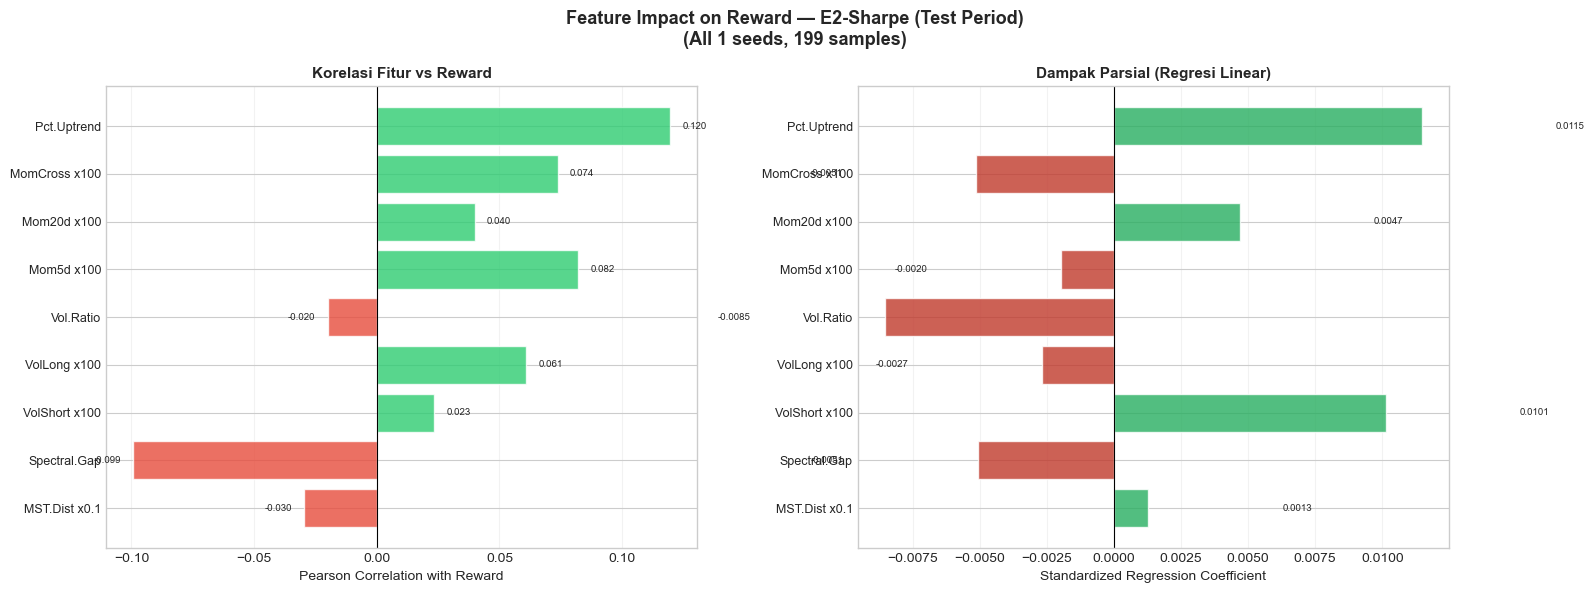


  === Feature Impact: E2-Sharpe ===


,Feature,Correlation,Reg_Coef (std),Impact
8,Pct.Uptrend,0.1196,0.0115,POSITIF (+)
2,VolShort x100,0.0235,0.0101,POSITIF (+)
6,Mom20d x100,0.0399,0.0047,Netral (~)
0,MST.Dist x0.1,-0.0296,0.0013,Netral (~)
5,Mom5d x100,0.0820,-0.0020,Netral (~)
3,VolLong x100,0.0608,-0.0027,Netral (~)
1,Spectral.Gap,-0.0994,-0.0051,NEGATIF (-)
7,MomCross x100,0.0737,-0.0051,NEGATIF (-)
4,Vol.Ratio,-0.0201,-0.0085,NEGATIF (-)


  ↑ Dampak POSITIF terbesar: Pct.Uptrend (coef=0.011500000022351742)
  ↓ Dampak NEGATIF terbesar: Vol.Ratio (coef=-0.008500000461935997)


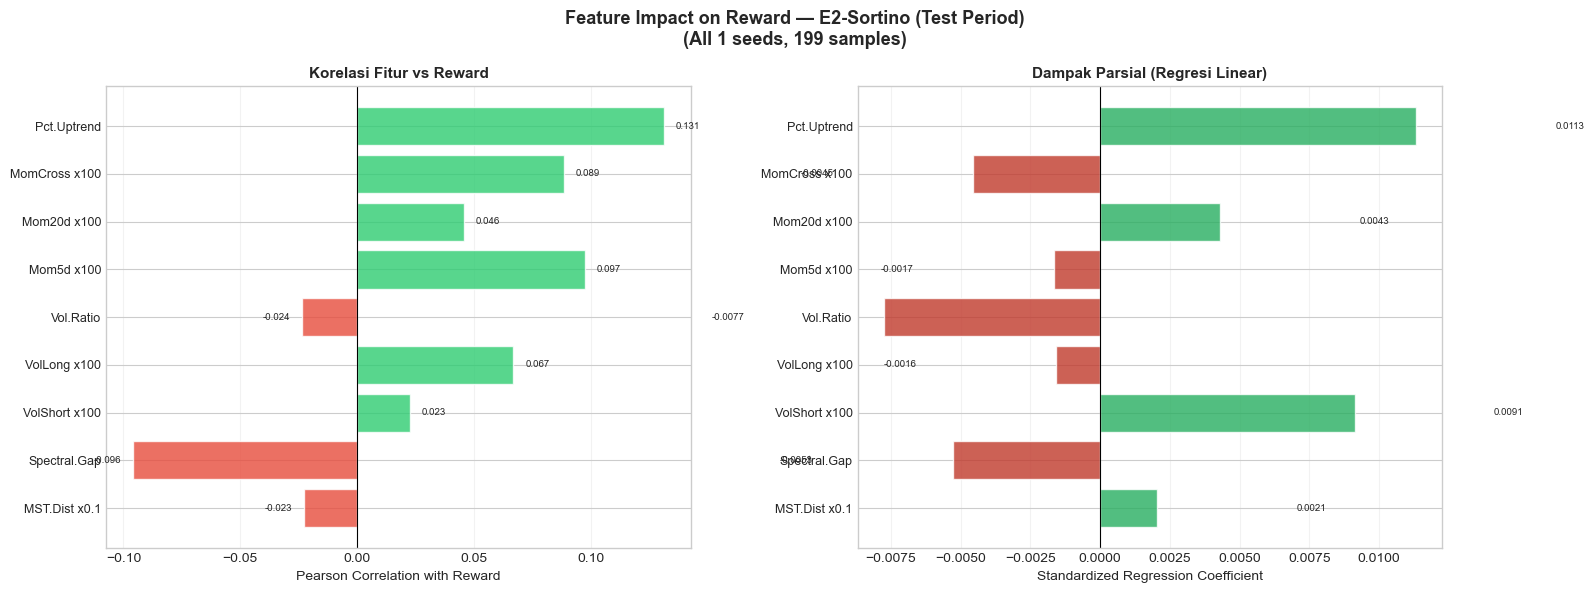


  === Feature Impact: E2-Sortino ===


,Feature,Correlation,Reg_Coef (std),Impact
8,Pct.Uptrend,0.1314,0.0113,POSITIF (+)
2,VolShort x100,0.0227,0.0091,POSITIF (+)
6,Mom20d x100,0.0457,0.0043,Netral (~)
0,MST.Dist x0.1,-0.0229,0.0021,Netral (~)
3,VolLong x100,0.0669,-0.0016,Netral (~)
5,Mom5d x100,0.0974,-0.0017,Netral (~)
7,MomCross x100,0.0885,-0.0045,Netral (~)
1,Spectral.Gap,-0.0960,-0.0053,NEGATIF (-)
4,Vol.Ratio,-0.0235,-0.0077,NEGATIF (-)


  ↑ Dampak POSITIF terbesar: Pct.Uptrend (coef=0.011300000362098217)
  ↓ Dampak NEGATIF terbesar: Vol.Ratio (coef=-0.007699999958276749)


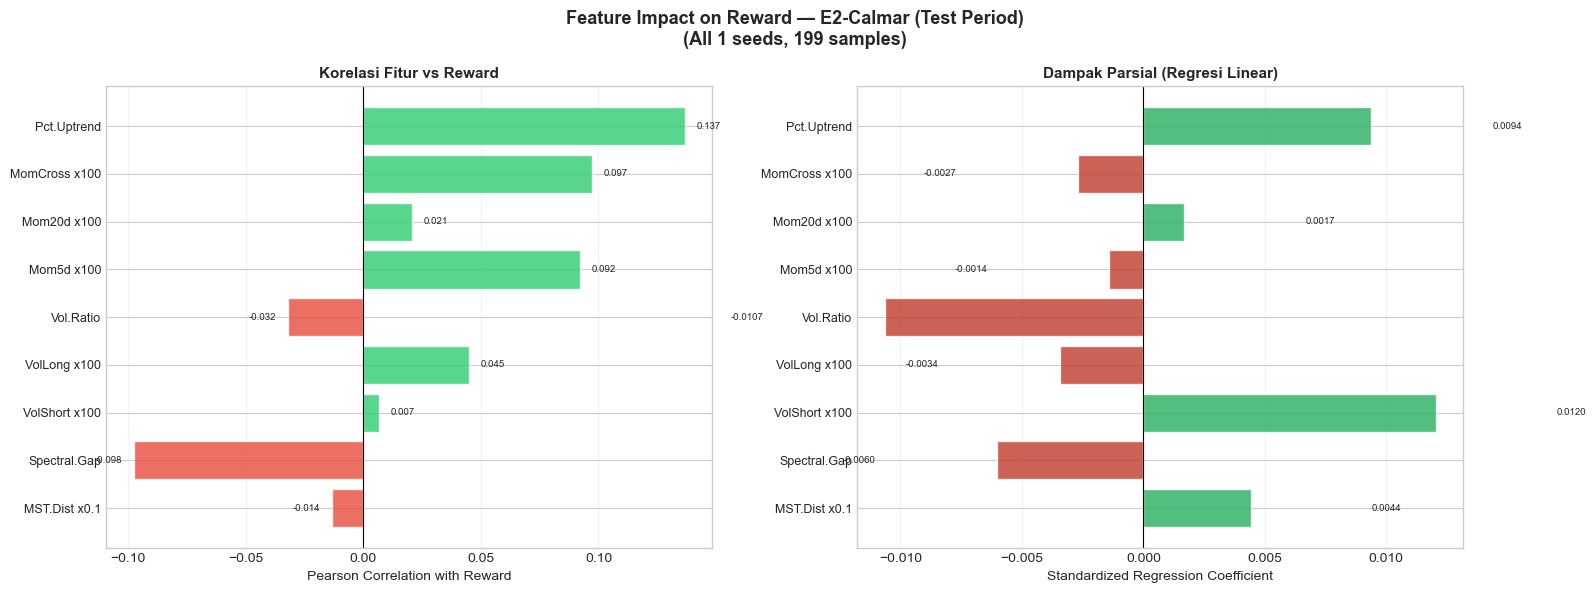


  === Feature Impact: E2-Calmar ===


,Feature,Correlation,Reg_Coef (std),Impact
2,VolShort x100,0.0067,0.0120,POSITIF (+)
8,Pct.Uptrend,0.1367,0.0094,POSITIF (+)
0,MST.Dist x0.1,-0.0135,0.0044,Netral (~)
6,Mom20d x100,0.0207,0.0017,Netral (~)
5,Mom5d x100,0.0922,-0.0014,Netral (~)
7,MomCross x100,0.0973,-0.0027,Netral (~)
3,VolLong x100,0.0450,-0.0034,Netral (~)
1,Spectral.Gap,-0.0977,-0.0060,NEGATIF (-)
4,Vol.Ratio,-0.0319,-0.0107,NEGATIF (-)


  ↑ Dampak POSITIF terbesar: VolShort x100 (coef=0.012000000104308128)
  ↓ Dampak NEGATIF terbesar: Vol.Ratio (coef=-0.010700000450015068)


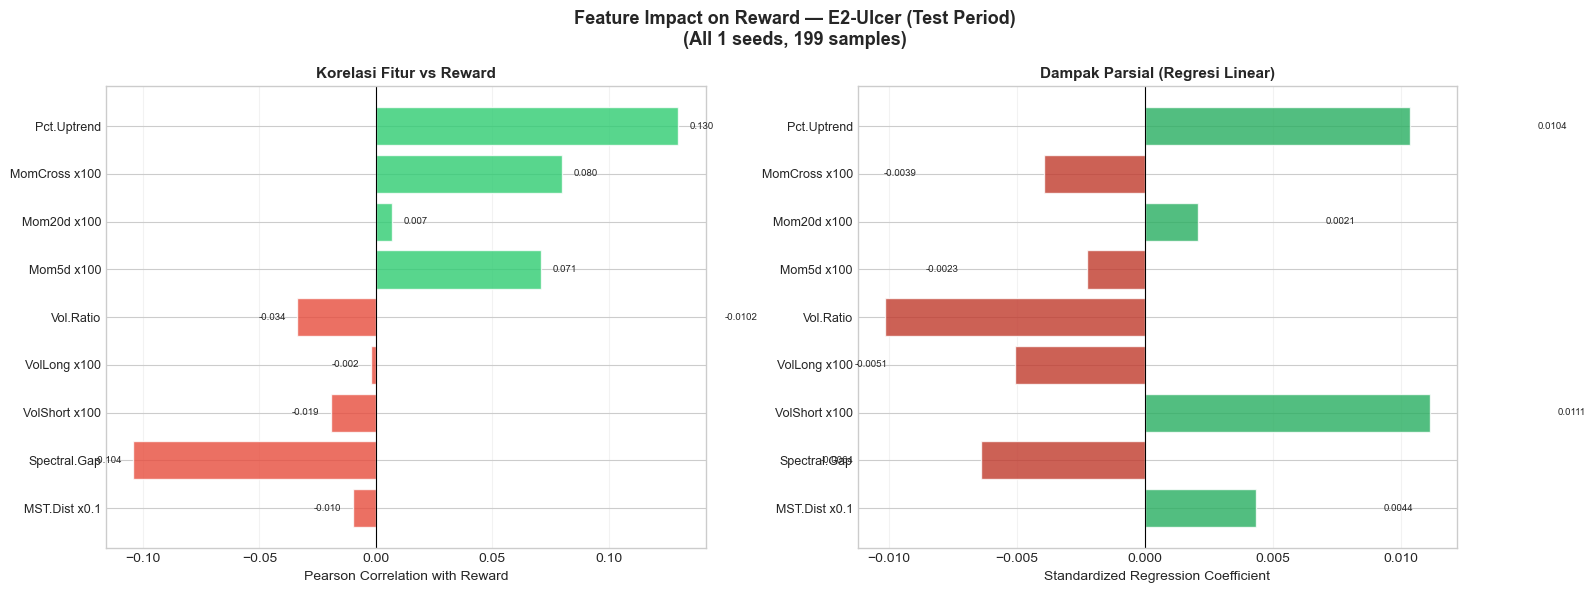


  === Feature Impact: E2-Ulcer ===


,Feature,Correlation,Reg_Coef (std),Impact
2,VolShort x100,-0.0192,0.0111,POSITIF (+)
8,Pct.Uptrend,0.1299,0.0104,POSITIF (+)
0,MST.Dist x0.1,-0.0097,0.0044,Netral (~)
6,Mom20d x100,0.0069,0.0021,Netral (~)
5,Mom5d x100,0.0708,-0.0023,Netral (~)
7,MomCross x100,0.0800,-0.0039,Netral (~)
3,VolLong x100,-0.0020,-0.0051,NEGATIF (-)
1,Spectral.Gap,-0.1041,-0.0064,NEGATIF (-)
4,Vol.Ratio,-0.0337,-0.0102,NEGATIF (-)


  ↑ Dampak POSITIF terbesar: VolShort x100 (coef=0.011099999770522118)
  ↓ Dampak NEGATIF terbesar: Vol.Ratio (coef=-0.010200000368058681)


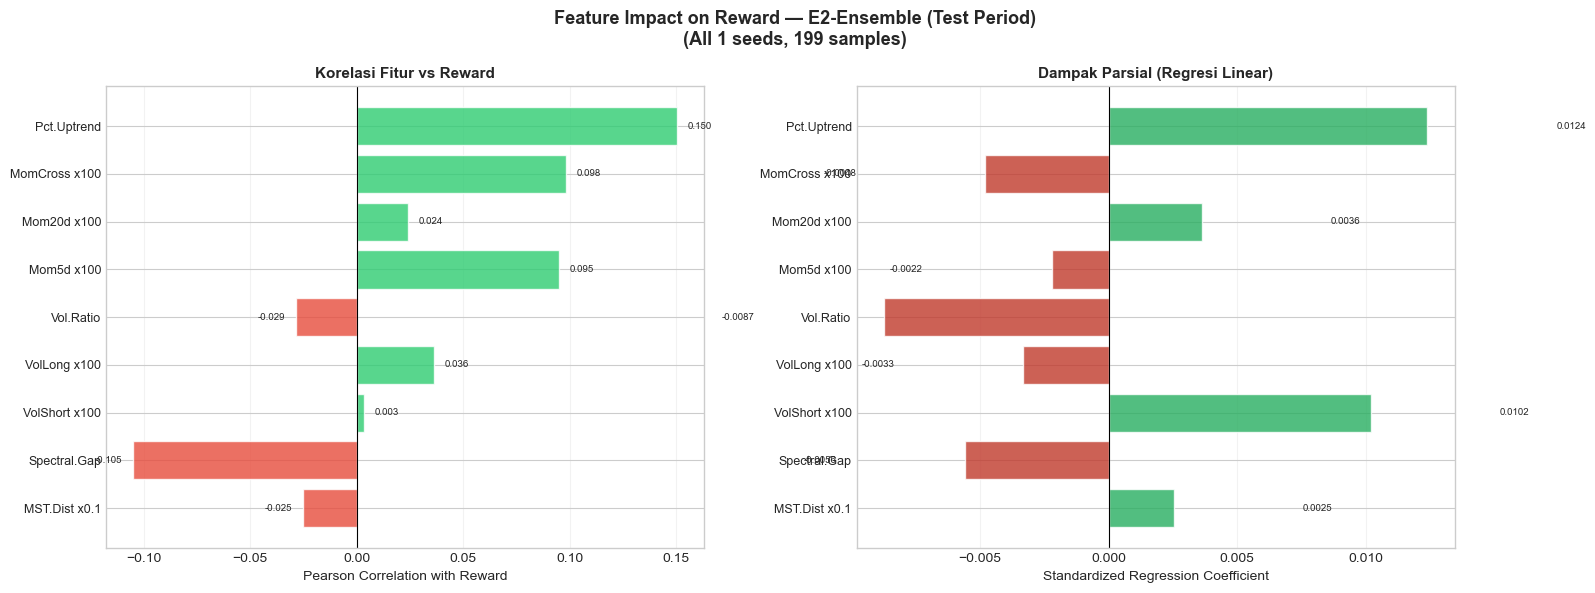


  === Feature Impact: E2-Ensemble ===


,Feature,Correlation,Reg_Coef (std),Impact
8,Pct.Uptrend,0.1503,0.0124,POSITIF (+)
2,VolShort x100,0.0032,0.0102,POSITIF (+)
6,Mom20d x100,0.0241,0.0036,Netral (~)
0,MST.Dist x0.1,-0.0252,0.0025,Netral (~)
5,Mom5d x100,0.0947,-0.0022,Netral (~)
3,VolLong x100,0.0361,-0.0033,Netral (~)
7,MomCross x100,0.0982,-0.0048,Netral (~)
1,Spectral.Gap,-0.1049,-0.0056,NEGATIF (-)
4,Vol.Ratio,-0.0286,-0.0087,NEGATIF (-)


  ↑ Dampak POSITIF terbesar: Pct.Uptrend (coef=0.012400000356137753)
  ↓ Dampak NEGATIF terbesar: Vol.Ratio (coef=-0.008700000122189522)

Feature Impact Analysis selesai.


In [17]:
# ═══════════════════════════════════════════════════════════════════════════════════
# 16. Feature Impact Analysis — Dampak Fitur terhadap Reward
# ═══════════════════════════════════════════════════════════════════════════════════
# Menggunakan data yang direkam saat backtesting (feature_log, reward_log)
# untuk model RL (E2_*) dengan konfigurasi use_network=True, use_market=True.
# ═══════════════════════════════════════════════════════════════════════════════════

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

impact_exp_ids = [eid for eid in feature_log if eid in ABLATION_CONFIGS
                  and ABLATION_CONFIGS[eid].get('use_network', False)
                  and ABLATION_CONFIGS[eid].get('use_market', False)]

for exp_id in tqdm(impact_exp_ids, desc='Feature Impact Analysis'):
    config = ABLATION_CONFIGS[exp_id]
    
    # Kumpulkan data dari semua seeds (test period)
    all_feats = []
    all_rewards = []
    for seed in SEEDS:
        feats = feature_log[exp_id]['test'].get(seed)
        rews  = reward_log[exp_id]['test'].get(seed)
        if feats is None or rews is None:
            continue
        n = min(len(feats), len(rews))
        all_feats.append(feats[:n])
        all_rewards.append(np.array(rews[:n]))
    
    if len(all_feats) == 0:
        print(f'  Skip {exp_id}: tidak ada data fitur.')
        continue
    
    X = np.concatenate(all_feats, axis=0)
    y = np.concatenate(all_rewards, axis=0)
    
    # ── 1. Korelasi Pearson ──
    corrs = []
    for j in range(X.shape[1]):
        c = np.corrcoef(X[:, j], y)[0, 1]
        corrs.append(c if not np.isnan(c) else 0.0)
    
    # ── 2. Regresi linear (standardized coefficients) ──
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    reg = LinearRegression().fit(Xs, y)
    coefs = reg.coef_
    
    # ── 3. Plot ──
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor='white')
    fig.suptitle(
        f'Feature Impact on Reward — {get_display_name(exp_id)} (Test Period)\n'
        f'(All {len(SEEDS)} seeds, {len(y)} samples)',
        fontsize=13, fontweight='bold'
    )
    
    # ── Panel kiri: correlation bar chart ──
    ax = axes[0]
    colors_corr = ['#e74c3c' if c < 0 else '#2ecc71' for c in corrs]
    bars = ax.barh(range(len(FEATURE_NAMES)), corrs, color=colors_corr, alpha=0.8, edgecolor='white')
    ax.set_yticks(range(len(FEATURE_NAMES)))
    ax.set_yticklabels(FEATURE_NAMES, fontsize=9)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Pearson Correlation with Reward', fontsize=10)
    ax.set_title('Korelasi Fitur vs Reward', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.25, axis='x')
    # Anotasi
    for bar, c in zip(bars, corrs):
        lbl = f'{c:.3f}'
        ax.text(c + 0.005 * (1 if c >= 0 else -1), bar.get_y() + bar.get_height()/2,
                lbl, va='center', ha='left' if c >=0 else 'right', fontsize=7)
    
    # ── Panel kanan: regression coefficients ──
    ax = axes[1]
    colors_coef = ['#c0392b' if c < 0 else '#27ae60' for c in coefs]
    bars = ax.barh(range(len(FEATURE_NAMES)), coefs, color=colors_coef, alpha=0.8, edgecolor='white')
    ax.set_yticks(range(len(FEATURE_NAMES)))
    ax.set_yticklabels(FEATURE_NAMES, fontsize=9)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Standardized Regression Coefficient', fontsize=10)
    ax.set_title('Dampak Parsial (Regresi Linear)', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.25, axis='x')
    for bar, c in zip(bars, coefs):
        lbl = f'{c:.4f}'
        ax.text(c + 0.005 * (1 if c >= 0 else -1), bar.get_y() + bar.get_height()/2,
                lbl, va='center', ha='left' if c >=0 else 'right', fontsize=7)
    
    plt.tight_layout()
    if SAVE_IMAGES:
        plt.savefig(os.path.join(OUTPUT_DIR, f'16_feature_impact_{exp_id}.png'), dpi=200, bbox_inches='tight')
    plt.show()
    plt.close()
    
    # ── 4. Print summary ──
    print(f'\n  === Feature Impact: {get_display_name(exp_id)} ===')
    impact_df = pd.DataFrame({
        'Feature': FEATURE_NAMES,
        'Correlation': [round(c, 4) for c in corrs],
        'Reg_Coef (std)': [round(c, 4) for c in coefs],
        'Impact': ['POSITIF (+)  ' if c > 0.005 else ('NEGATIF (-)  ' if c < -0.005 else 'Netral (~)') for c in coefs]
    }).sort_values('Reg_Coef (std)', ascending=False)
    display(impact_df)
    
    # Highlight fitur dominan
    pos_max = impact_df[impact_df['Reg_Coef (std)'] > 0].head(1)
    neg_max = impact_df[impact_df['Reg_Coef (std)'] < 0].tail(1)
    if len(pos_max) > 0:
        r = pos_max.iloc[0]
        print(f'  ↑ Dampak POSITIF terbesar: {r["Feature"]} (coef={r["Reg_Coef (std)"]})')
    if len(neg_max) > 0:
        r = neg_max.iloc[0]
        print(f'  ↓ Dampak NEGATIF terbesar: {r["Feature"]} (coef={r["Reg_Coef (std)"]})')

print('\nFeature Impact Analysis selesai.')
